# 08 — Posture and Free-Running Motion

## What this notebook is for

Understanding what the orientation and motion sensors actually contain, and whether the
differences between people are visible in them. It does not rank features or decide what
goes into a model — with six participants and overlapping windows, any number here is too
fragile to carry that weight. The plots are the output.

Notebook 05 looked at the 300ms around each tap. This one looks at **everything else**:
roughly 45,000 orientation and 45,000 motion samples describing how the phone is held
between interactions.

## What the three orientation angles mean

Worth being concrete, because the names are unhelpful and the physical meaning drives
every interpretation below.

| angle | axis | what it measures | typical value here |
|---|---|---|---|
| **beta** | front–back | how far the top of the phone tips away from you | 20–70° |
| **gamma** | left–right | how far the phone rolls about its long axis | −9° to +5° |
| **alpha** | compass | which way the phone points relative to north | 0–360°, wraps |

Beta is mostly **where your body is** — upright in a chair, reclined on a sofa, lying down.
Gamma is mostly **how you hold it** — a hand that habitually rotates the phone slightly.
Alpha is **which way you were facing**, which is about the room, not the person.

Motion is separate: `ax/ay/az` are linear acceleration with gravity removed, so they
measure movement rather than attitude.

## What changed in this version

**v2** added Sections 5 and 6. One participant confirmed after the fact that they
deliberately varied body position between sessions, which explains the between-session
posture splits in Section 4 and turns them from an anomaly into ground truth. That raised
a question the first version did not ask: if absolute tilt is mostly *where the body was*,
can it be subtracted off to leave the part that is about the hand? Section 5 works through
how to choose a baseline for that subtraction under the constraint that a
continuous-authentication system can only ever look backwards in time. Section 6 looks at
what survives the subtraction.

**v3** is a robustness pass, prompted by the cohort growing from 13 to 20 sessions and 6 to
9 participants. Two things the plots were doing silently, verified against the new export
before fixing:

- One session (p95MPVX s2) has a 51.7s orientation dropout. Plotted without a break, it
  draws a straight line across the gap that looks exactly like a slow reposition. Lines now
  break wherever consecutive samples are more than 0.5s apart.
- Beta wraps (crosses the +-180 boundary) in exactly one session (pAFQRTM s1) in this
  cohort. Left unwrapped it inflates that session's spread, drift rate and total path by
  roughly 3-4x and made it a repeated outlier across several charts for the wrong reason.
  Beta is now unwrapped before any statistic or plot uses it; gamma never wraps here and is
  left alone.

Also new: gamma becomes unreliable once beta is near +-90 (the Euler-angle singularity —
front/back tilt and left/right roll stop being independent there). pH3S4X4 s4, at a median
beta of 80.8 deg, is the clearest case in this cohort and is now outlined wherever gamma is
plotted. The session used to demonstrate baseline choice is now chosen only from sessions
free of both problems.

## Sections

1. What is in the streams, and how fast they sample
2. Posture over a session — the raw traces
3. Posture distributions, per session and per person
4. The same person across their own sessions
5. **Choosing a baseline — separating posture from wobble** *(new)*
6. **What survives centring** *(new)*
7. Movement: what "holding still" looks like
8. Who can be measured, and who cannot
9. Restlessness while not interacting
10. Frequency content
11. The alpha wrap, and why circular means are necessary
12. Two sensors, one quantity: a consistency check
13. Per-participant summary
14. Data-quality notes and open questions

## 1. What is in the streams

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle, FancyArrow

pd.set_option('display.max_columns', 60); pd.set_option('display.width', 210)
mpl.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.22,
                     'axes.titlesize': 11, 'axes.labelsize': 10, 'legend.fontsize': 9})

_CANDIDATES = ["../../data/processed/raw_events.parquet",
               "../../data/processed/raw_events.csv",
               "data/processed/raw_events.parquet",
               "/mnt/user-data/uploads/raw_events.parquet"]
_src = next((p for p in _CANDIDATES if Path(p).exists()), None)
if _src is None:
    raise FileNotFoundError(f"no raw events file found; tried {_CANDIDATES}")
raw_all = (pd.read_parquet(_src) if _src.endswith(".parquet")
           else pd.read_csv(_src, low_memory=False))

raw_all['deviceFamily'] = raw_all['deviceFamily'].astype(str).str.lower()
raw_all['tRelMs'] = pd.to_numeric(raw_all['tRelMs'], errors='coerce')
raw_all = raw_all.loc[raw_all['tRelMs'].notna()].copy()
raw = raw_all.loc[raw_all['deviceFamily'] == 'mobile'].copy()

ORIENT_KIND, MOTION_KIND = 'deviceorientation', 'devicemotion'
ACCEL_COLS = ['payload_ax', 'payload_ay', 'payload_az']
GRAVITY_COLS = ['payload_agx', 'payload_agy', 'payload_agz']
INTERACTION_KINDS = ['keydown', 'keyup', 'input', 'touchstart', 'touchmove', 'touchend',
                     'scroll', 'window_scroll', 'carousel_scroll', 'pointerdown',
                     'pointerup', 'click']
ANGLES = {'payload_beta': 'beta — front/back tilt',
          'payload_gamma': 'gamma — left/right roll'}

session_index = (raw.groupby(['participantId', 'sessionId'], dropna=False)
                 .agg(duration_s=('tRelMs', lambda s: s.max() / 1000.0),
                      started=('timestampIso', 'min')).reset_index())
session_index['session_start'] = pd.to_datetime(session_index['started'], utc=True, errors='coerce')
session_index = session_index.sort_values(['participantId', 'session_start']).reset_index(drop=True)
session_index['session_no'] = session_index.groupby('participantId').cumcount() + 1
SESSION_LABEL = {r.sessionId: f"{r.participantId} s{r.session_no}" for r in session_index.itertuples()}
SESSION_ORDER = session_index.sort_values(['participantId', 'session_no'])['sessionId'].tolist()

_p_dur = session_index.groupby('participantId')['duration_s'].median().sort_values(ascending=False)
PARTICIPANTS = _p_dur.index.astype(str).tolist()   # slowest session first
PCOL = {p: plt.get_cmap('turbo')((i + 0.5) / max(1, len(PARTICIPANTS)))
        for i, p in enumerate(PARTICIPANTS)}
def pcolor(p): return PCOL.get(str(p), '0.5')

inventory = (raw.loc[raw['kind'].isin([ORIENT_KIND, MOTION_KIND])]
             .groupby(['participantId', 'kind']).size().unstack(fill_value=0)
             .reindex(PARTICIPANTS))
inventory['sessions'] = session_index.groupby('participantId').size().reindex(PARTICIPANTS)
inventory['total_minutes'] = (session_index.groupby('participantId')['duration_s'].sum()
                              .reindex(PARTICIPANTS) / 60).round(1)

print(f"Loaded {_src}")
print(f"mobile only: {raw['sessionId'].nunique()} sessions, {len(PARTICIPANTS)} participants\n")
print(inventory.to_string())

Loaded ../../data/processed/raw_events.parquet
mobile only: 20 sessions, 9 participants

kind           devicemotion  deviceorientation  sessions  total_minutes
participantId                                                          
p3M6E7Z               14353              14278         1           15.9
pAFQRTM               10629              10516         1           11.7
p95MPVX               15778              15635         2           20.3
pZMC82M                5635               5568         1            7.3
pH3S4X4               31269              30935         6           44.7
pUNKH7L                5010               4922         1            6.0
p3YDMHG               10798              10668         2           11.9
pA6XL23                9287               9232         2           10.6
pG5G4MS                7812               7731         4            9.5


In [2]:
# --- shared helpers added in this version --------------------------------
# Verified against the full 20-session export: beta wraps in exactly one
# session (pAFQRTM s1); gamma never wraps in this cohort. Orientation streams
# have gaps up to ~52s (sensor backgrounded / occluded); plotting straight
# through them draws a fake straight-line "reposition" that isn't real.

GAP_BREAK_S = 0.5   # gaps wider than this get a break in the drawn line


def unwrap_deg(v):
    """Remove +-180 wrap discontinuities from a bounded circular series."""
    v = np.asarray(v, float)
    ok = np.isfinite(v)
    out = v.copy()
    if ok.sum() > 1:
        out[ok] = np.degrees(np.unwrap(np.radians(v[ok])))
    return out


def break_on_gaps(t, v, max_gap=GAP_BREAK_S):
    """Insert a NaN sample at each gap wider than max_gap so plot lines break
    instead of drawing a straight line across missing data."""
    t = np.asarray(t, float); v = np.asarray(v, float)
    if len(t) < 2:
        return t, v
    dt = np.diff(t)
    gap_idx = np.where(dt > max_gap)[0]
    if len(gap_idx) == 0:
        return t, v
    t_ins = t[gap_idx] + dt[gap_idx] / 2.0
    t2 = np.insert(t, gap_idx + 1, t_ins)
    v2 = np.insert(v, gap_idx + 1, np.nan)
    return t2, v2


def session_max_gap_s(sess, kind=ORIENT_KIND):
    t = np.sort(sess.loc[sess['kind'] == kind, 'tRelMs'].to_numpy(float)) / 1000.0
    if len(t) < 2:
        return np.inf
    return float(np.diff(t).max())


def session_singularity(sess, col='payload_beta', thresh=75.0):
    """True if this session spends its median time near the beta/gamma
    Euler-angle singularity (beta ~ +-90), where gamma becomes ill-defined."""
    v = pd.to_numeric(sess.loc[sess['kind'] == ORIENT_KIND, col],
                      errors='coerce').dropna().to_numpy()
    return len(v) > 0 and abs(float(np.median(v))) > thresh


# a longer marker cycle: pH3S4X4 now has 6 sessions, the old 5-marker cycle
# repeated a shape within one participant
SESSION_MARKERS = ['o', '^', 's', 'D', 'v', 'P', 'X', '*']

# a qualitative palette reads better than turbo once colours must stay
# distinguishable across 9 people rather than 6
_QUAL = plt.get_cmap('tab10')
PCOL = {p: _QUAL(i % 10) for i, p in enumerate(PARTICIPANTS)}
def pcolor(p): return PCOL.get(str(p), '0.5')

### 1.1 How fast do the sensors sample, and what does that cost us?

Sampling rate sets a hard ceiling on what can be seen. Anything oscillating faster than
half the sampling rate — the Nyquist frequency — cannot be represented and gets folded
back into the signal as a false lower frequency.

That matters here because hand tremor lives at roughly 8–12 Hz. The plot below shows
where the sampling limit falls relative to that band.

              min  median   max
stream                         
motion       20.0    20.0  20.0
orientation  20.0    20.0  20.0

At 20 Hz the Nyquist limit is 10 Hz.
Hand tremor sits at 8-12 Hz, so it is at or beyond the limit: any energy seen up
there is partly real and partly aliased from higher frequencies. Read it as a
rough indicator of 'how much fast wobble', not as a tremor measurement.


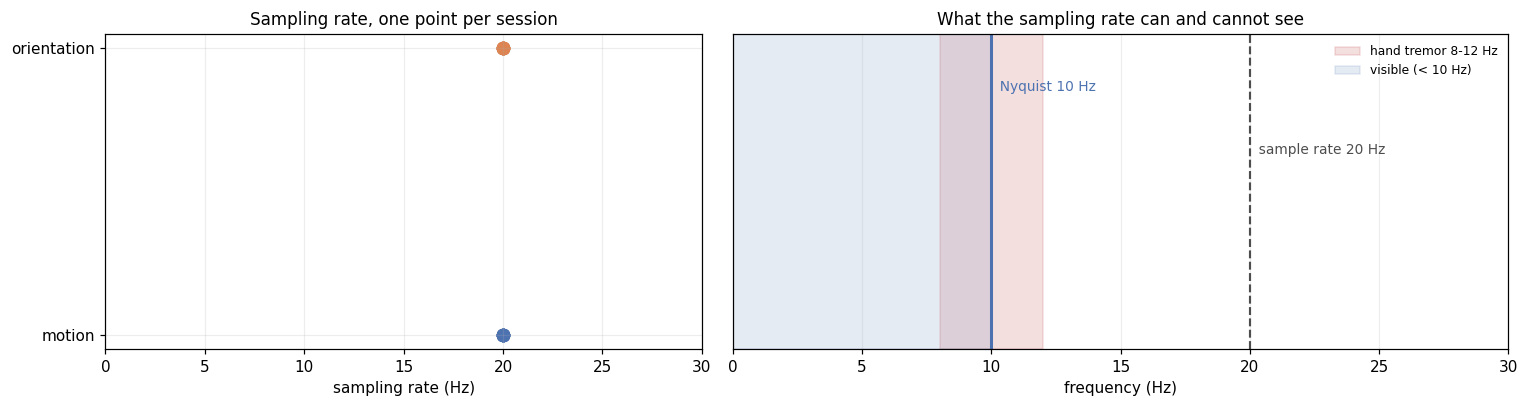

In [3]:
_rates = []
for sid, g in raw.groupby('sessionId'):
    for kind, label in ((MOTION_KIND, 'motion'), (ORIENT_KIND, 'orientation')):
        t = np.sort(g.loc[g['kind'] == kind, 'tRelMs'].to_numpy(float))
        if len(t) < 20:
            continue
        d = np.diff(t); d = d[(d > 0) & (d < 1000)]
        _rates.append({'sessionId': sid, 'stream': label, 'n': len(t),
                       'median_dt_ms': float(np.median(d)), 'hz': 1000.0 / float(np.median(d))})
rates = pd.DataFrame(_rates)
SAMPLE_HZ = float(rates.loc[rates['stream'] == 'motion', 'hz'].median())
NYQUIST_HZ = SAMPLE_HZ / 2.0


def plot_sampling(rates_df):
    fig, axes = plt.subplots(1, 2, figsize=(14, 3.8), gridspec_kw={'width_ratios': [1, 1.3]})
    ax = axes[0]
    for i, (stream, g) in enumerate(rates_df.groupby('stream')):
        ax.scatter(g['hz'], [i] * len(g), s=60, alpha=0.7,
                   color=['#4c72b0', '#dd8452'][i % 2])
    ax.set_yticks(range(rates_df['stream'].nunique()))
    ax.set_yticklabels(sorted(rates_df['stream'].unique()))
    ax.set_xlabel("sampling rate (Hz)"); ax.set_xlim(0, max(30, rates_df['hz'].max() * 1.2))
    ax.set_title("Sampling rate, one point per session")

    ax = axes[1]
    f = np.linspace(0, 30, 400)
    ax.axvspan(8, 12, color='#c44e52', alpha=0.18, label='hand tremor 8-12 Hz')
    ax.axvspan(0, NYQUIST_HZ, color='#4c72b0', alpha=0.14, label=f'visible (< {NYQUIST_HZ:.0f} Hz)')
    ax.axvline(NYQUIST_HZ, color='#4c72b0', lw=2)
    ax.axvline(SAMPLE_HZ, color='0.3', ls='--', lw=1.4)
    ax.text(NYQUIST_HZ, 0.82, f'  Nyquist {NYQUIST_HZ:.0f} Hz', fontsize=9, color='#4c72b0')
    ax.text(SAMPLE_HZ, 0.62, f'  sample rate {SAMPLE_HZ:.0f} Hz', fontsize=9, color='0.3')
    ax.set_yticks([]); ax.set_xlim(0, 30); ax.set_xlabel("frequency (Hz)")
    ax.set_title("What the sampling rate can and cannot see")
    ax.legend(loc='upper right', frameon=False, fontsize=8)
    plt.tight_layout(); plt.show(); plt.close(fig)


print(rates.groupby('stream')['hz'].agg(['min', 'median', 'max']).round(1).to_string())
print(f"\nAt {SAMPLE_HZ:.0f} Hz the Nyquist limit is {NYQUIST_HZ:.0f} Hz.")
print("Hand tremor sits at 8-12 Hz, so it is at or beyond the limit: any energy seen up")
print("there is partly real and partly aliased from higher frequencies. Read it as a")
print("rough indicator of 'how much fast wobble', not as a tremor measurement.")
plot_sampling(rates)

## 2. Posture over a session — the raw traces

The most direct view: every orientation sample, unsmoothed, for every session.

What to look for is whether the lines are **flat**. A flat line means the phone stayed at
one angle for the whole session. A ramp would mean gradual slumping; a step would mean the
person repositioned.

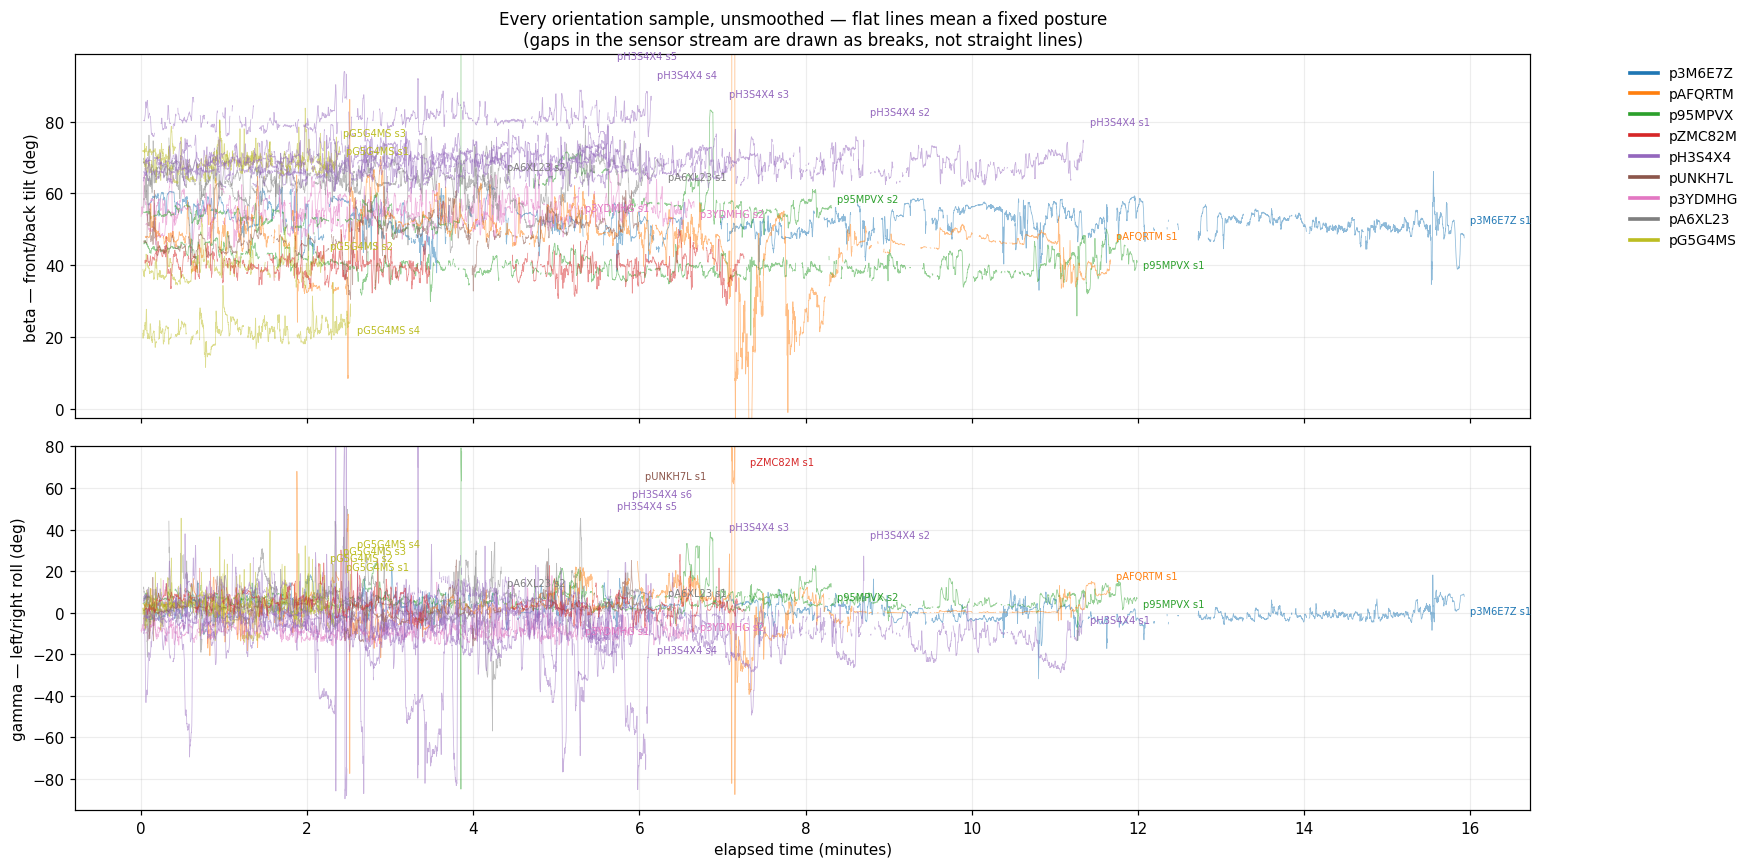

In [4]:
MIN_ORIENT = 300


def plot_raw_traces(raw_df):
    # beta wraps in exactly one session in this cohort (pAFQRTM s1); gaps up
    # to ~52s occur in several sessions (sensor backgrounded/occluded). Left
    # unhandled, a wrap draws a spike to +-180 and a gap draws a fake straight
    # "reposition" line -- both would be read as real behaviour.
    fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
    label_y_used = {0: [], 1: []}
    for row, (ax, (col, name)) in enumerate(zip(axes, ANGLES.items())):
        vmin, vmax = np.inf, -np.inf
        for sid in SESSION_ORDER:
            s = raw_df.loc[raw_df['sessionId'] == sid]
            o = s.loc[s['kind'] == ORIENT_KIND].sort_values('tRelMs')
            v = pd.to_numeric(o[col], errors='coerce').to_numpy(float)
            t = o['tRelMs'].to_numpy(float) / 1000.0
            ok = np.isfinite(v)
            if ok.sum() < MIN_ORIENT:
                continue
            if col == 'payload_beta':
                # unwrap only, do NOT rewrap to [-180,180] -- rewrapping recreates
                # the exact +-180 discontinuity the unwrap exists to remove. The
                # unwrapped series can legitimately sit outside [-180,180]; the
                # y-limits below are computed from percentiles so one wrapped
                # session doesn't stretch everyone else's axis.
                v = unwrap_deg(v)
            t_b, v_b = break_on_gaps(t[ok], v[ok])
            p = s['participantId'].iloc[0]
            ax.plot(t_b / 60.0, v_b, color=pcolor(p), lw=0.5, alpha=0.5, rasterized=True)
            med = float(np.nanmedian(v[ok]))
            vmin, vmax = min(vmin, np.nanpercentile(v[ok], 0.5)), max(vmax, np.nanpercentile(v[ok], 99.5))
            # stagger labels vertically so nearby session-ends don't overlap
            y_txt = med
            used = label_y_used[row]
            span = max(vmax - vmin, 1.0)
            while any(abs(y_txt - u) < span * 0.035 for u in used):
                y_txt += span * 0.035
            used.append(y_txt)
            ax.annotate(SESSION_LABEL.get(sid, ''), (t[ok][-1] / 60.0, y_txt),
                        fontsize=6.5, color=pcolor(p), xytext=(4, 0),
                        textcoords='offset points', va='center')
        pad = 0.08 * max(vmax - vmin, 1.0)
        ax.set_ylim(vmin - pad, vmax + pad)
        ax.set_ylabel(f"{name} (deg)")
    axes[0].set_title("Every orientation sample, unsmoothed — flat lines mean a fixed posture\n"
                      "(gaps in the sensor stream are drawn as breaks, not straight lines)")
    axes[1].set_xlabel("elapsed time (minutes)")
    handles = [Line2D([0], [0], color=pcolor(p), lw=2.4, label=p) for p in PARTICIPANTS]
    axes[0].legend(handles=handles, bbox_to_anchor=(1.06, 1), loc='upper left', frameon=False)
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_raw_traces(raw)

In [5]:
def session_angle_summary(raw_df):
    rows = []
    for sid in SESSION_ORDER:
        s = raw_df.loc[raw_df['sessionId'] == sid]
        o = s.loc[s['kind'] == ORIENT_KIND].sort_values('tRelMs')
        rec = {'session': SESSION_LABEL.get(sid, sid[:8]),
               'participantId': s['participantId'].iloc[0], 'sessionId': sid,
               'minutes': round(s['tRelMs'].max() / 60000.0, 1)}
        for col, name in ANGLES.items():
            v = pd.to_numeric(o[col], errors='coerce').to_numpy(float)
            t = o['tRelMs'].to_numpy(float) / 1000.0
            ok = np.isfinite(v)
            if ok.sum() < MIN_ORIENT:
                continue
            v2, t2 = v[ok], t[ok]
            short = col.split('_')[-1]
            rec[f'{short}_median'] = round(float(np.median(v2)), 1)
            rec[f'{short}_iqr'] = round(float(np.percentile(v2, 75) - np.percentile(v2, 25)), 1)
            rec[f'{short}_quartile_range'] = round(
                float(max(np.median(x) for x in np.array_split(v2, 4))
                      - min(np.median(x) for x in np.array_split(v2, 4))), 1)
            rec[f'{short}_drift_per_min'] = round(float(np.polyfit(t2, v2, 1)[0] * 60), 2)
        rows.append(rec)
    return pd.DataFrame(rows)


angle_summary = session_angle_summary(raw)
print("Per session. 'quartile_range' compares the four quarters of the session to each")
print("other, so it detects repositioning; 'iqr' is the moment-to-moment spread.\n")
print(angle_summary.drop(columns=['sessionId', 'participantId']).to_string(index=False))

Per session. 'quartile_range' compares the four quarters of the session to each
other, so it detects repositioning; 'iqr' is the moment-to-moment spread.

   session  minutes  beta_median  beta_iqr  beta_quartile_range  beta_drift_per_min  gamma_median  gamma_iqr  gamma_quartile_range  gamma_drift_per_min
p3M6E7Z s1     15.9         52.5       5.1                  3.0               -0.18           0.7        5.9                   4.7                -0.26
p3YDMHG s1      5.3         55.9       4.5                  0.2               -0.06          -8.7        4.2                   2.1                -0.24
p3YDMHG s2      6.7         54.2       4.0                  2.4                0.59          -9.3        4.3                   1.5                 0.18
p95MPVX s1     12.0         39.9       4.2                  4.1               -0.22           4.4        3.8                   1.2                 0.17
p95MPVX s2      8.3         55.0       5.0                 11.6                0.74  

## 3. Distributions — per session and per person

The traces show flat lines; the distributions show how tightly. A person holding one
posture gives a narrow peak. Two narrow peaks in different places, across sessions, means
the posture changed between visits rather than during one.

The right panel pools each participant's sessions together, which is what a model would
see if it treated posture as a personal characteristic.

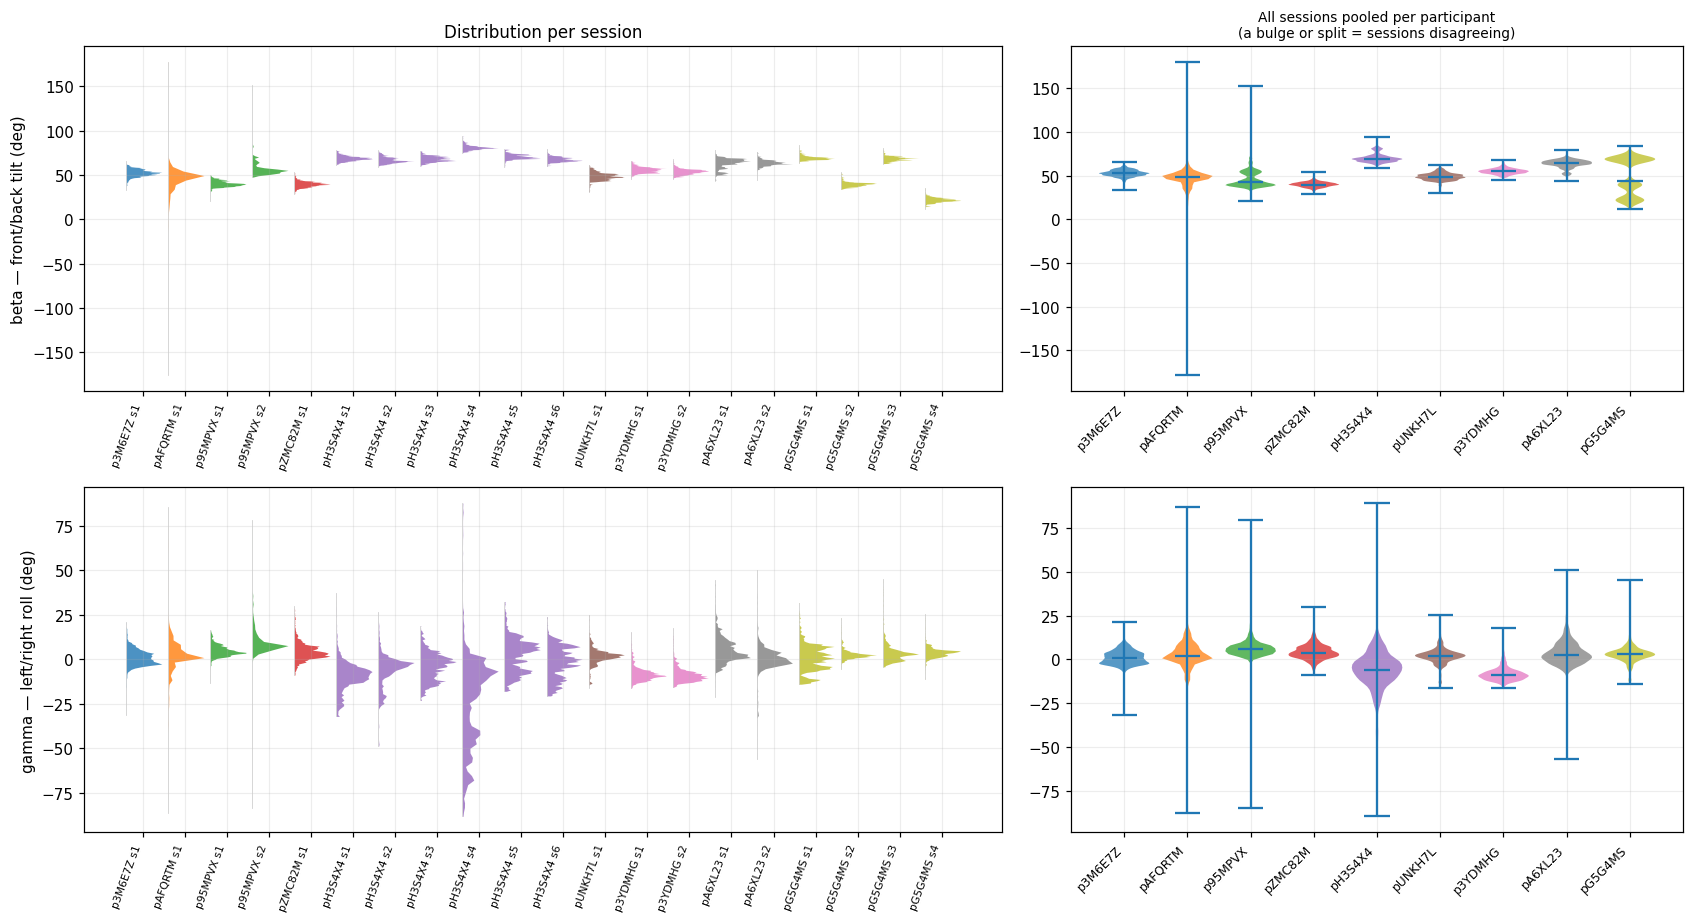

In [6]:
def plot_distributions(raw_df):
    fig, axes = plt.subplots(2, 2, figsize=(15.5, 8.5), gridspec_kw={'width_ratios': [1.5, 1]})
    for row, (col, name) in enumerate(ANGLES.items()):
        # per-session ridgelines
        ax = axes[row, 0]
        labels, offset = [], 0
        for p in PARTICIPANTS:
            for sid in session_index.loc[session_index['participantId'] == p, 'sessionId']:
                v = pd.to_numeric(raw_df.loc[(raw_df['sessionId'] == sid)
                                             & (raw_df['kind'] == ORIENT_KIND), col],
                                  errors='coerce').dropna().to_numpy()
                if len(v) < MIN_ORIENT:
                    continue
                hist, edges = np.histogram(v, bins=70, density=True)
                if hist.max() > 0:
                    hist = hist / hist.max() * 0.85
                mids = (edges[:-1] + edges[1:]) / 2
                ax.fill_betweenx(mids, offset, offset + hist, color=pcolor(p), alpha=0.8, lw=0)
                ax.plot([offset, offset], [mids.min(), mids.max()], color='0.8', lw=0.5)
                labels.append(SESSION_LABEL.get(sid, sid[:6])); offset += 1
        ax.set_xticks(np.arange(len(labels)) + 0.4)
        ax.set_xticklabels(labels, rotation=70, ha='right', fontsize=7)
        ax.set_ylabel(f"{name} (deg)")
        if row == 0:
            ax.set_title("Distribution per session")

        # pooled per participant
        ax = axes[row, 1]
        data, names, colors = [], [], []
        for p in PARTICIPANTS:
            v = pd.to_numeric(raw_df.loc[(raw_df['participantId'] == p)
                                         & (raw_df['kind'] == ORIENT_KIND), col],
                              errors='coerce').dropna().to_numpy()
            if len(v) < MIN_ORIENT:
                continue
            data.append(v); names.append(p); colors.append(pcolor(p))
        parts = ax.violinplot(data, showmedians=True, widths=0.8)
        for body, c in zip(parts['bodies'], colors):
            body.set_facecolor(c); body.set_alpha(0.75)
        ax.set_xticks(range(1, len(names) + 1))
        ax.set_xticklabels(names, rotation=45, ha='right', fontsize=8)
        if row == 0:
            ax.set_title("All sessions pooled per participant\n(a bulge or split = sessions "
                         "disagreeing)", fontsize=9)
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_distributions(raw)

## 4. The same person, across their own sessions

The observation worth understanding from this notebook.

Posture is essentially **fixed within a session** and can be **completely different between
sessions**. Below, each participant's sessions are overlaid: same colour, different line
style. Where the lines sit on top of each other, that person held the phone the same way
on both visits. Where they separate, they did not.

This matters for two reasons. It means posture describes **the recording** at least as much
as the person — so a window's session is often readable from its tilt alone. And it means
any evaluation that mixes windows from one session across training and testing will get
credit for recognising the session rather than the person. P1's session-safe splits already
prevent that; it's worth knowing what they are preventing.

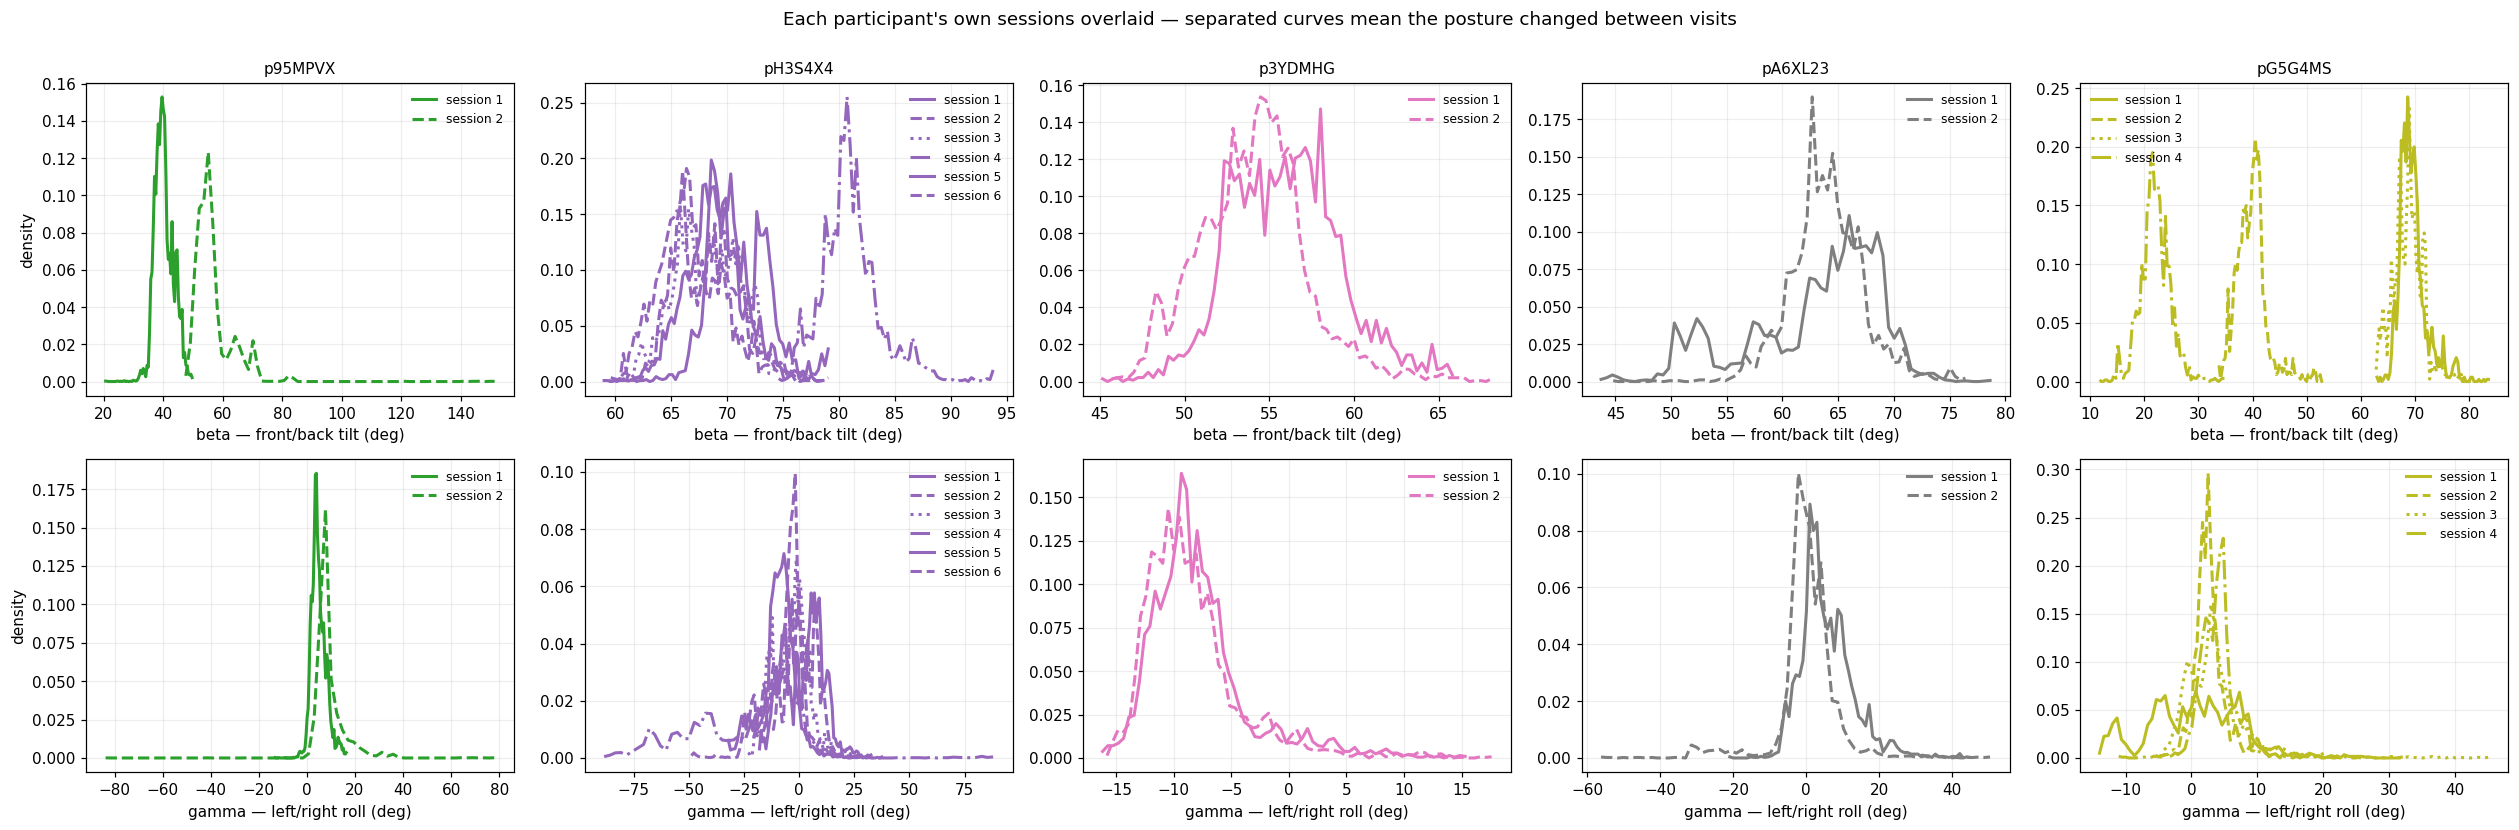

single-session participants (no comparison possible): p3M6E7Z, pAFQRTM, pZMC82M, pUNKH7L


In [7]:
def plot_same_person(raw_df):
    reps = [p for p in PARTICIPANTS
            if session_index.loc[session_index['participantId'] == p, 'sessionId'].nunique() > 1]
    singles = [p for p in PARTICIPANTS if p not in reps]
    n = len(reps)
    fig, axes = plt.subplots(2, max(n, 1), figsize=(4.6 * max(n, 1), 7.5), squeeze=False)
    styles = ['-', '--', ':', '-.']
    for j, p in enumerate(reps):
        sids = session_index.loc[session_index['participantId'] == p, 'sessionId'].tolist()
        for row, (col, name) in enumerate(ANGLES.items()):
            ax = axes[row, j]
            for k, sid in enumerate(sids):
                v = pd.to_numeric(raw_df.loc[(raw_df['sessionId'] == sid)
                                             & (raw_df['kind'] == ORIENT_KIND), col],
                                  errors='coerce').dropna().to_numpy()
                if len(v) < MIN_ORIENT:
                    continue
                hist, edges = np.histogram(v, bins=70, density=True)
                mids = (edges[:-1] + edges[1:]) / 2
                ax.plot(mids, hist, color=pcolor(p), ls=styles[k % len(styles)], lw=2,
                        label=f"session {k + 1}")
            ax.set_xlabel(f"{name} (deg)")
            if row == 0:
                ax.set_title(p, fontsize=10)
            if j == 0:
                ax.set_ylabel("density")
            ax.legend(frameon=False, fontsize=8)
    fig.suptitle("Each participant's own sessions overlaid — separated curves mean the "
                 "posture changed between visits", y=1.0)
    plt.tight_layout(); plt.show(); plt.close(fig)
    if singles:
        print(f"single-session participants (no comparison possible): {', '.join(singles)}")


plot_same_person(raw)

3,119 windows with at least 20 orientation samples

Each cluster below is a session. Where one colour forms two separate clusters,
that participant sat differently on their two visits. Points outlined in black
have beta beyond +-75 deg, close enough to the Euler-angle singularity that
their gamma should not be read as ordinary roll.


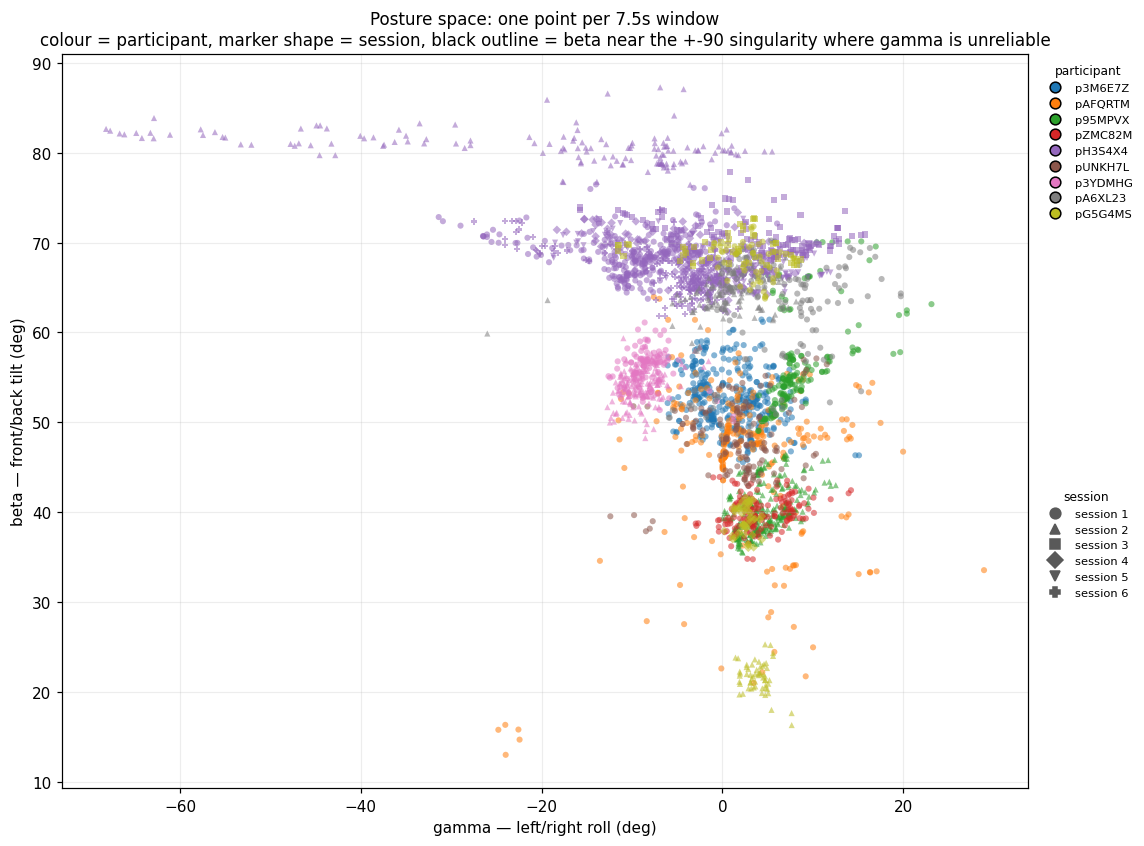

In [8]:
CA_WINDOW_S, CA_STRIDE_S = 7.5, 2.5
MIN_ORIENT_PER_WINDOW = 20


def build_windows(raw_df):
    rows = []
    for sid, s in raw_df.groupby('sessionId'):
        o = s.loc[s['kind'] == ORIENT_KIND].sort_values('tRelMs')
        ot = o['tRelMs'].to_numpy(float) / 1000.0
        cols = {c: pd.to_numeric(o[c], errors='coerce').to_numpy(float)
                for c in ['payload_beta', 'payload_gamma', 'payload_alpha']}
        cols['payload_beta'] = unwrap_deg(cols['payload_beta'])
        m = s.loc[s['kind'] == MOTION_KIND].sort_values('tRelMs')
        mt = m['tRelMs'].to_numpy(float) / 1000.0
        mag = np.sqrt(sum(pd.to_numeric(m[c], errors='coerce').to_numpy(float) ** 2
                          for c in ACCEL_COLS))
        end = s['tRelMs'].max() / 1000.0
        lo = 0.0
        while lo + CA_WINDOW_S <= end:
            om = (ot >= lo) & (ot < lo + CA_WINDOW_S)
            if om.sum() >= MIN_ORIENT_PER_WINDOW:
                mm = (mt >= lo) & (mt < lo + CA_WINDOW_S)
                rows.append({'participantId': s['participantId'].iloc[0], 'sessionId': sid,
                             'window_start_s': lo,
                             'beta': float(np.nanmedian(cols['payload_beta'][om])),
                             'gamma': float(np.nanmedian(cols['payload_gamma'][om])),
                             'beta_spread': float(np.nanstd(cols['payload_beta'][om])),
                             'motion_median': float(np.nanmedian(mag[mm])) if mm.sum() > 3 else np.nan})
            lo += CA_STRIDE_S
    return pd.DataFrame(rows)


windows = build_windows(raw)


def plot_posture_space(w):
    # colour=participant, marker=session -- with up to 6 sessions for one
    # participant, a two-part legend (colour swatches + shape key) reads far
    # better than one legend entry per session, which no longer fits.
    fig, ax = plt.subplots(figsize=(10.5, 7.8))
    singular = {p: session_singularity(raw.loc[raw['sessionId'] == sid])
                for p in PARTICIPANTS
                for sid in session_index.loc[session_index['participantId'] == p, 'sessionId']}
    for p in PARTICIPANTS:
        d = w.loc[w['participantId'] == p]
        for j, (sid, g) in enumerate(d.groupby('sessionId')):
            is_sing = singular.get(sid, False)
            ax.scatter(g['gamma'], g['beta'], s=16, alpha=0.55, color=pcolor(p),
                       marker=SESSION_MARKERS[j % len(SESSION_MARKERS)],
                       edgecolor='k' if is_sing else 'none', linewidth=0.6 if is_sing else 0)
    ax.set_xlabel("gamma — left/right roll (deg)")
    ax.set_ylabel("beta — front/back tilt (deg)")
    ax.set_title("Posture space: one point per 7.5s window\n"
                 "colour = participant, marker shape = session, black outline = beta near "
                 "the +-90 singularity where gamma is unreliable")
    colour_handles = [Line2D([0], [0], marker='o', color='none', markerfacecolor=pcolor(p),
                             markersize=7, label=p) for p in PARTICIPANTS]
    shape_handles = [Line2D([0], [0], marker=SESSION_MARKERS[j], color='0.35', linestyle='none',
                            markersize=7, label=f"session {j + 1}")
                     for j in range(min(6, len(SESSION_MARKERS)))]
    leg1 = ax.legend(handles=colour_handles, bbox_to_anchor=(1.005, 1), loc='upper left',
                     frameon=False, fontsize=7.5, title='participant', title_fontsize=8)
    ax.add_artist(leg1)
    ax.legend(handles=shape_handles, bbox_to_anchor=(1.005, 0.42), loc='upper left',
              frameon=False, fontsize=7.5, title='session', title_fontsize=8)
    plt.tight_layout(); plt.show(); plt.close(fig)


print(f"{len(windows):,} windows with at least {MIN_ORIENT_PER_WINDOW} orientation samples\n")
print("Each cluster below is a session. Where one colour forms two separate clusters,")
print("that participant sat differently on their two visits. Points outlined in black")
print("have beta beyond +-75 deg, close enough to the Euler-angle singularity that")
print("their gamma should not be read as ordinary roll.")
plot_posture_space(windows)

## 5. Choosing a baseline — separating posture from wobble

Section 4 established the problem. Absolute tilt says more about the recording than about
the person: one participant's four sessions sit at 69°, 22°, 69° and 40°, a spread of 47°,
while the moment-to-moment variation inside any one session is only a few degrees.

That participant has since confirmed the cause directly — they sat, lay down and stood for
different sessions on purpose. So the between-session spread is not sensor drift or noise.
It is body position, faithfully recorded.

Which suggests a decomposition. A single tilt reading is roughly

```
tilt(t)  =  where the body is  +  how the hand is holding it right now
            ├─ changes between sessions      ├─ changes second to second
            └─ about the room and the chair  └─ about the person
```

The first term is what makes tilt a session fingerprint. The second is the part that might
be behavioural. Subtracting a **baseline** is how you separate them — and the entire
question is what that baseline should be.

### 5.1 First, what the questionnaire said

Before deriving posture from the sensor, it is worth checking what the participants
themselves reported, since the context questionnaire asks about posture directly.

   session reported_posture reported_movement  measured_tilt_deg
p3M6E7Z s1          sitting              none               52.5
p3YDMHG s1          sitting              none               55.9
p3YDMHG s2          sitting              none               54.2
p95MPVX s1          sitting              none               39.9
p95MPVX s2          sitting   slight_movement               55.0
pA6XL23 s1          sitting              none               64.6
pA6XL23 s2          sitting              none               63.8
pAFQRTM s1          sitting              none               48.1
pG5G4MS s1          sitting              none               69.1
pG5G4MS s2          sitting              none               39.8
pG5G4MS s3          sitting              none               68.7
pG5G4MS s4          sitting              none               21.9
pH3S4X4 s1          sitting              none               68.8
pH3S4X4 s2          sitting              none               66.3
pH3S4X4 s3          sitti

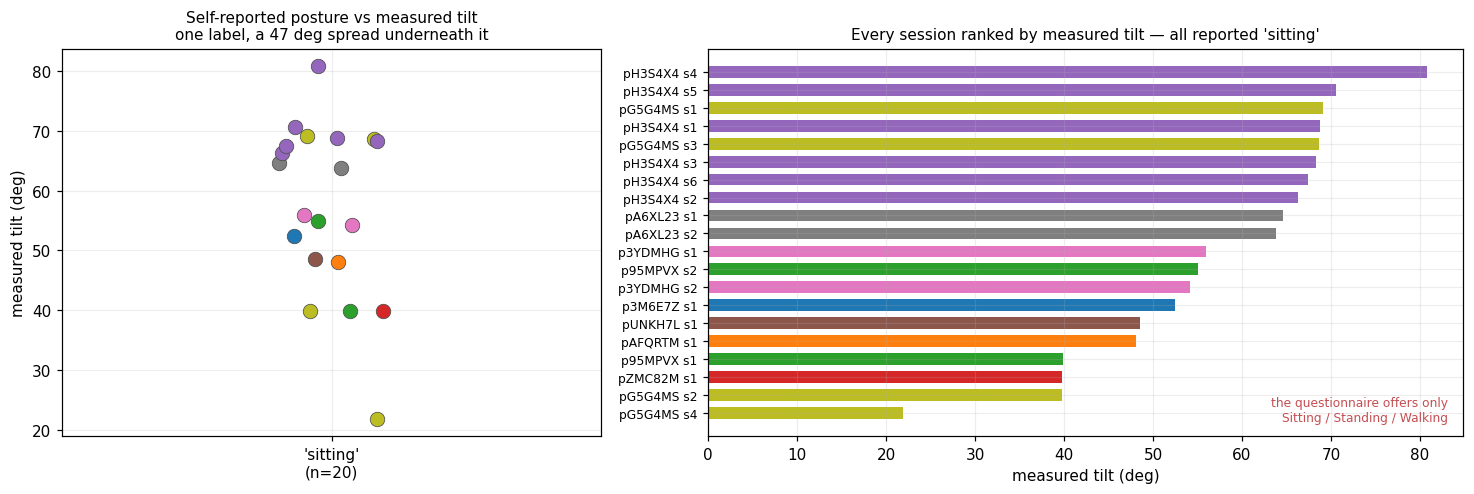

In [9]:
# --- what was self-reported, against what the sensor measured --------------
_ctx = (raw.groupby(['participantId', 'sessionId'])
        .agg(reported_posture=('ctxPosture', 'first'),
             reported_movement=('ctxMovement', 'first')).reset_index())
_meas = (raw.loc[raw['kind'] == ORIENT_KIND]
         .groupby('sessionId')['payload_beta']
         .apply(lambda s: round(float(pd.to_numeric(s, errors='coerce').median()), 1))
         .rename('measured_tilt_deg').reset_index())
posture_check = _ctx.merge(_meas, on='sessionId')
posture_check['session'] = posture_check['sessionId'].map(SESSION_LABEL)
posture_check = (posture_check.sort_values(['participantId', 'session'])
                 [['session', 'reported_posture', 'reported_movement', 'measured_tilt_deg']])

print(posture_check.to_string(index=False))
print(f"\ndistinct self-reported postures across all sessions: "
      f"{posture_check['reported_posture'].nunique()}")
print(f"range of measured tilt across the same sessions: "
      f"{posture_check['measured_tilt_deg'].min():.0f}-"
      f"{posture_check['measured_tilt_deg'].max():.0f} deg")


def plot_reported_vs_measured(pc):
    fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6),
                             gridspec_kw={'width_ratios': [1, 1.4]})
    ax = axes[0]
    labels = sorted(pc['reported_posture'].astype(str).unique())
    for i, lab in enumerate(labels):
        sub = pc.loc[pc['reported_posture'].astype(str) == lab]
        jitter = np.random.uniform(-0.12, 0.12, len(sub))
        for (x, r) in zip(jitter, sub.itertuples()):
            p = r.session.split()[0]
            ax.scatter(i + x, r.measured_tilt_deg, s=90, color=pcolor(p),
                       edgecolor='0.3', lw=0.5, zorder=3)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels([f"'{l}'\n(n={int((pc['reported_posture'].astype(str) == l).sum())})"
                        for l in labels])
    ax.set_xlim(-0.6, len(labels) - 0.4)
    ax.set_ylabel("measured tilt (deg)")
    ax.set_title("Self-reported posture vs measured tilt\n"
                 "one label, a 47 deg spread underneath it", fontsize=10)

    ax = axes[1]
    order = pc.sort_values('measured_tilt_deg')
    y = np.arange(len(order))
    ax.barh(y, order['measured_tilt_deg'],
            color=[pcolor(s.split()[0]) for s in order['session']], height=0.65)
    ax.set_yticks(y); ax.set_yticklabels(order['session'], fontsize=8)
    ax.set_xlabel("measured tilt (deg)")
    ax.set_title("Every session ranked by measured tilt — all reported 'sitting'",
                 fontsize=10)
    ax.text(0.98, 0.04, "the questionnaire offers only\nSitting / Standing / Walking",
            transform=ax.transAxes, ha='right', fontsize=8, color='#c44e52')
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_reported_vs_measured(posture_check)

Every session in the cohort reports the same posture, while the sensor spans 22° to 69°
across those same sessions.

This is not participants answering carelessly. The app offers three options — *Sitting*,
*Standing*, *Walking / moving* — and there is no option for lying down or reclining. The
list is built around **locomotion** ("am I moving?") when the thing that actually
determines device orientation is **body position**. A participant lying on a sofa picks
the nearest available label, which is "Sitting", and the record is wrong through no fault
of theirs.

Two consequences worth carrying:

- `ctxPosture` cannot be used as a context variable in this cohort. It has zero variance,
  and the zero variance is an artefact of the option set rather than a fact about the
  participants.
- The sensor is the better instrument here. It recovered a context variable the
  self-report could not express — which is a small but clean argument for passive sensing
  over questionnaires.

### 5.2 Four candidate baselines, and the constraint that rules two of them out

The obvious baseline is the session median: the middle tilt across the whole recording.
For describing data in a notebook it is the right choice, and Sections 2–4 use it.

For a **feature**, it is not available. A continuous-authentication system decides at time
*t* using only what has happened up to *t*. The session median needs the whole session,
including the part that has not been recorded yet. A feature built on it would work
perfectly in analysis and be uncomputable in deployment.

There is a second, quieter problem: every window in a session would help define its own
baseline. Windows here already overlap by 5 of every 7.5 seconds; centring on the session
median couples them completely. That is the same family of mistake as fitting scaler
statistics before splitting the data.

So the candidates split into two groups:

| baseline | definition | usable as a feature? |
|---|---|---|
| session median | middle of the whole session | no — needs the future |
| value at t = 0 | one reading at the start | yes, but one noisy sample |
| expanding median | median of everything so far | yes |
| rolling median | median of the last 30 s | yes |
| EWMA | exponentially fading average | yes |

The last three are all causal. They differ in **memory**: how long ago something has to be
before it stops counting. That is the same dial as a long versus short moving average in a
price series, and the trade is identical — long memory is steadier but slow to notice a
change, short memory reacts quickly but is jumpier.

clearest repositioning session: pA6XL23 s1 (quartile range 8.8 deg)
excluded from selection (sensor gap > 15s or beta near the singularity): p3M6E7Z s1, p95MPVX s2, pH3S4X4 s4, pZMC82M s1



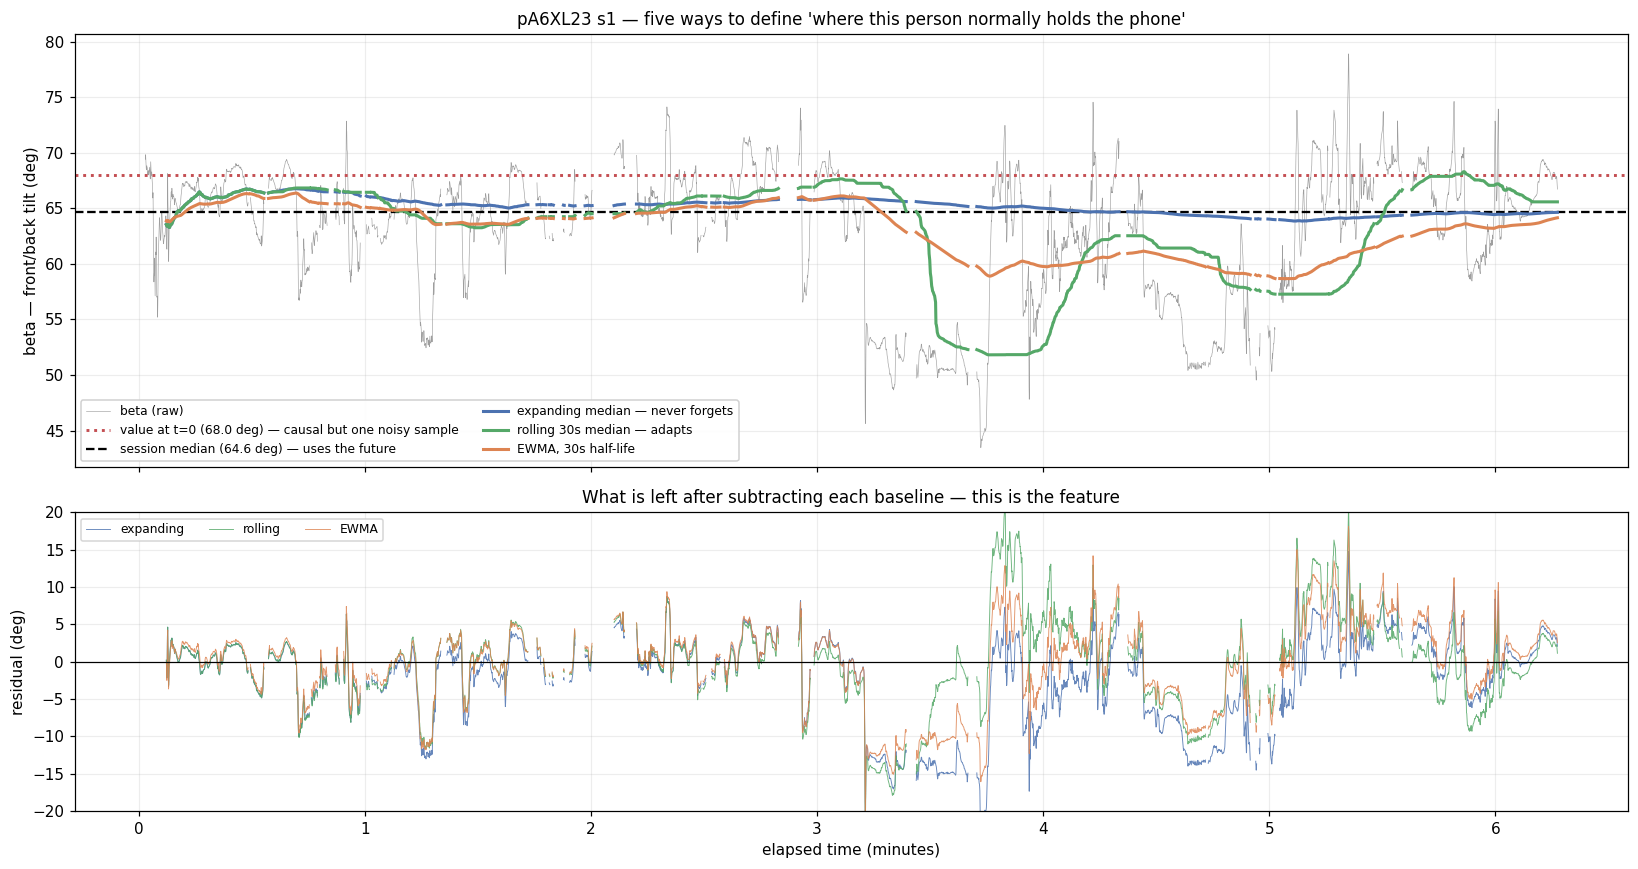

In [10]:
# --- causal baselines ------------------------------------------------------
BASE_WINDOW_S = 30.0      # memory length for rolling median and EWMA half-life
WARMUP_S = 5.0            # minimum evidence before a baseline is considered defined

_n_roll = max(20, int(round(BASE_WINDOW_S * SAMPLE_HZ)))
_n_warm = max(10, int(round(WARMUP_S * SAMPLE_HZ)))


def causal_baselines(v):
    """Backward-looking baselines for a 1-D orientation series (uniform sampling)."""
    s = pd.Series(np.asarray(v, float))
    return {
        'expanding': s.expanding(min_periods=_n_warm).median().to_numpy(),
        'rolling': s.rolling(_n_roll, min_periods=_n_warm).median().to_numpy(),
        'ewma': s.ewm(halflife=_n_roll, min_periods=_n_warm).mean().to_numpy(),
    }


def orientation_series(sess, col='payload_beta'):
    o = sess.loc[sess['kind'] == ORIENT_KIND].sort_values('tRelMs')
    t = o['tRelMs'].to_numpy(float) / 1000.0
    v = pd.to_numeric(o[col], errors='coerce').to_numpy(float)
    if col == 'payload_beta':
        # unwrap only -- rewrapping to [-180,180] here would recreate the same
        # discontinuity the unwrap removes, since this session's beta legitimately
        # sits outside that range once unwrapped (verified: -12 to +186 for the
        # one session that wraps in this cohort, vs -178.5/+179.9 before fixing)
        v = unwrap_deg(v)
    ok = np.isfinite(v) & np.isfinite(t)
    return t[ok], v[ok]


# The clearest case is the session with a genuine mid-session reposition: the
# one whose quartile_range is largest in the Section 2 table, EXCLUDING any
# session with a large sensor gap (a straight line across missing data looks
# exactly like a slow reposition) or with beta near the +-90 singularity
# (gamma becomes unreliable there, distorting the quartile-range statistic
# itself). Both exclusions were added after the auto-selection picked a
# gap-affected session on an earlier export.
GAP_EXCLUDE_S = 15.0  # verified: most sessions have brief (<12s) occlusion gaps that
                      # don't visibly distort a 30s-memory baseline; only the handful
                      # with gaps this long (p95MPVX s2 at 52s, pZMC82M s1 at 60s,
                      # p3M6E7Z s1 at 26s) produce a real artifact
_qr = angle_summary.dropna(subset=['beta_quartile_range']).copy()
_qr['max_gap_s'] = _qr['sessionId'].map(
    lambda sid: session_max_gap_s(raw.loc[raw['sessionId'] == sid]))
_qr['singular'] = _qr['sessionId'].map(
    lambda sid: session_singularity(raw.loc[raw['sessionId'] == sid]))
_qr_clean = _qr.loc[(_qr['max_gap_s'] <= GAP_EXCLUDE_S) & (~_qr['singular'])]
_excluded = _qr.loc[~_qr.index.isin(_qr_clean.index)]
DEMO_SID = _qr_clean.loc[_qr_clean['beta_quartile_range'].idxmax(), 'sessionId']
DEMO_LABEL = SESSION_LABEL.get(DEMO_SID, DEMO_SID[:8])
print(f"clearest repositioning session: {DEMO_LABEL} "
      f"(quartile range {_qr_clean['beta_quartile_range'].max():.1f} deg)")
if len(_excluded):
    print(f"excluded from selection (sensor gap > {GAP_EXCLUDE_S:.0f}s or beta near "
          f"the singularity): {', '.join(SESSION_LABEL.get(s, s[:8]) for s in _excluded['sessionId'])}")
print()


def plot_baseline_choices(sid):
    s = raw.loc[raw['sessionId'] == sid]
    t, v = orientation_series(s)
    bases = causal_baselines(v)
    anchor = float(np.median(v[t <= WARMUP_S])) if (t <= WARMUP_S).any() else float(v[0])
    sess_med = float(np.median(v))
    t_b, v_b = break_on_gaps(t, v)

    fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True,
                             gridspec_kw={'height_ratios': [1.45, 1]})
    ax = axes[0]
    ax.plot(t_b / 60.0, v_b, lw=0.4, color='0.62', label='beta (raw)', rasterized=True)
    ax.axhline(anchor, color='#c44e52', ls=':', lw=1.9,
               label=f'value at t=0 ({anchor:.1f} deg) — causal but one noisy sample')
    ax.axhline(sess_med, color='k', ls='--', lw=1.5,
               label=f'session median ({sess_med:.1f} deg) — uses the future')
    for key, lab, c in [('expanding', 'expanding median — never forgets', '#4c72b0'),
                        ('rolling', f'rolling {BASE_WINDOW_S:.0f}s median — adapts', '#55a868'),
                        ('ewma', f'EWMA, {BASE_WINDOW_S:.0f}s half-life', '#dd8452')]:
        tb2, vb2 = break_on_gaps(t, bases[key])
        ax.plot(tb2 / 60.0, vb2, color=c, lw=2.0, label=lab)
    ax.set_ylabel("beta — front/back tilt (deg)")
    ax.set_title(f"{DEMO_LABEL} — five ways to define 'where this person normally holds "
                 f"the phone'")
    ax.legend(fontsize=8, ncol=2, loc='lower left', framealpha=0.9)

    ax = axes[1]
    for key, lab, c in [('expanding', 'expanding', '#4c72b0'),
                        ('rolling', 'rolling', '#55a868'),
                        ('ewma', 'EWMA', '#dd8452')]:
        tb2, rb2 = break_on_gaps(t, v - bases[key])
        ax.plot(tb2 / 60.0, rb2, lw=0.6, color=c, alpha=0.85, label=lab, rasterized=True)
    ax.axhline(0, color='k', lw=0.8)
    ax.set_ylim(-20, 20)
    ax.set_xlabel("elapsed time (minutes)"); ax.set_ylabel("residual (deg)")
    ax.set_title("What is left after subtracting each baseline — this is the feature")
    ax.legend(fontsize=8, ncol=3)
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_baseline_choices(DEMO_SID)

The top panel shows why memory length matters. Around the repositioning, the expanding
median barely moves — it has minutes of the old posture already banked, so a new posture
cannot outvote it. The rolling median follows within its 30-second memory. The EWMA lands
between them.

The bottom panel is the consequence. During the reposition the expanding baseline reports
a large sustained residual, which reads as violent hand movement when the person actually
just settled into a new position and held it. The rolling baseline reports a spike during
the transition and then returns to zero, which is the honest description.

### 5.3 How much does the anchor choice actually cost?

The single-reading anchor is the tempting one, because "relative to the start of the
session" is the natural way to phrase the idea. The problem is that the start of a session
is the least typical moment in it — the phone is being picked up and the grip is still
settling.

The table below asks how far each candidate sits from a stable estimate of the session's
own typical posture, and compares that to the size of the wobble being measured.

Error of each anchor against the session's own median, in degrees.
Compare each error against that session's within_session_sd: an anchor error
larger than the wobble means the baseline is noisier than the signal.

   session  within_session_sd  err_first_sample  err_first_5s  err_first_30s
p3M6E7Z s1               3.92              4.54           NaN           6.21
p3YDMHG s1               3.24              2.34          0.34           0.77
p3YDMHG s2               3.16              2.78          2.71           2.62
p95MPVX s1               3.11              6.06          6.12           4.76
p95MPVX s2               6.79              0.25          0.25           0.65
pA6XL23 s1               6.01              4.77          3.33           2.03
pA6XL23 s2               3.28              7.81          1.68           1.80
pAFQRTM s1              12.08              0.07          0.17           0.11
pG5G4MS s1               2.55              0.38          0.96           0.28
pG5G4MS s2     

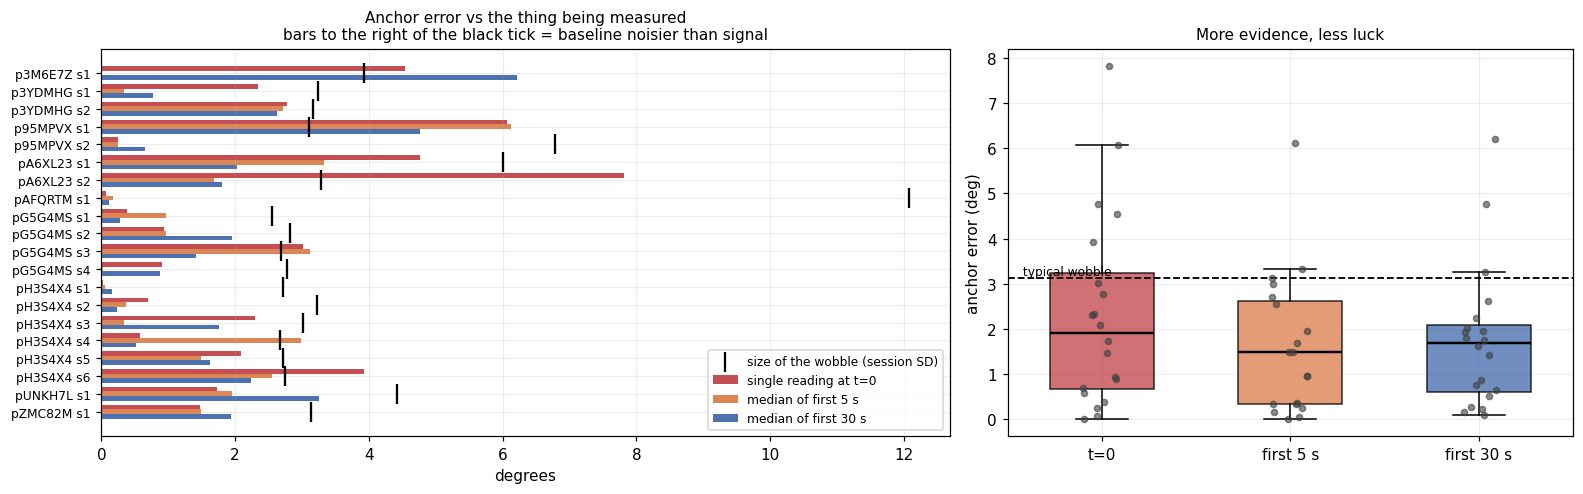

In [11]:
# --- how noisy is each anchor, relative to the thing being measured? -------
_rows = []
for sid in SESSION_ORDER:
    s = raw.loc[raw['sessionId'] == sid]
    t, v = orientation_series(s)
    if len(v) < MIN_ORIENT:
        continue
    med = float(np.median(v))
    first_sample = float(v[0])
    first_5s = float(np.median(v[t <= 5.0])) if (t <= 5.0).any() else np.nan
    first_30s = float(np.median(v[t <= 30.0])) if (t <= 30.0).any() else np.nan
    _rows.append({'session': SESSION_LABEL.get(sid, sid[:8]), 'sessionId': sid,
                  'within_session_sd': round(float(np.std(v)), 2),
                  'err_first_sample': round(abs(first_sample - med), 2),
                  'err_first_5s': round(abs(first_5s - med), 2),
                  'err_first_30s': round(abs(first_30s - med), 2)})
anchor_err = pd.DataFrame(_rows)

print("Error of each anchor against the session's own median, in degrees.")
print("Compare each error against that session's within_session_sd: an anchor error")
print("larger than the wobble means the baseline is noisier than the signal.\n")
print(anchor_err.drop(columns='sessionId').to_string(index=False))
print("\nmedian anchor error:")
for c in ['err_first_sample', 'err_first_5s', 'err_first_30s']:
    print(f"  {c:18s} {anchor_err[c].median():5.2f} deg")


def plot_anchor_error(ae):
    fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.6),
                             gridspec_kw={'width_ratios': [1.5, 1]})
    ax = axes[0]
    y = np.arange(len(ae)); w = 0.26
    for k, (c, lab, col) in enumerate([('err_first_sample', 'single reading at t=0', '#c44e52'),
                                       ('err_first_5s', 'median of first 5 s', '#dd8452'),
                                       ('err_first_30s', 'median of first 30 s', '#4c72b0')]):
        ax.barh(y + (k - 1) * w, ae[c], height=w, color=col, label=lab)
    ax.scatter(ae['within_session_sd'], y, color='k', marker='|', s=180, zorder=5,
               label='size of the wobble (session SD)')
    ax.set_yticks(y); ax.set_yticklabels(ae['session'], fontsize=8); ax.invert_yaxis()
    ax.set_xlabel("degrees")
    ax.set_title("Anchor error vs the thing being measured\n"
                 "bars to the right of the black tick = baseline noisier than signal",
                 fontsize=10)
    ax.legend(fontsize=8, loc='lower right')

    ax = axes[1]
    labs = ['t=0', 'first 5 s', 'first 30 s']
    cols = ['err_first_sample', 'err_first_5s', 'err_first_30s']
    bp = ax.boxplot([ae[c].dropna() for c in cols], patch_artist=True, showfliers=False,
                    widths=0.55, medianprops={'color': 'black', 'lw': 1.6})
    for patch, col in zip(bp['boxes'], ['#c44e52', '#dd8452', '#4c72b0']):
        patch.set_facecolor(col); patch.set_alpha(0.8)
    for i, c in enumerate(cols):
        vals = ae[c].dropna()
        ax.scatter(np.full(len(vals), i + 1) + np.random.uniform(-0.1, 0.1, len(vals)),
                   vals, s=16, color='0.25', alpha=0.6, zorder=3)
    ax.axhline(ae['within_session_sd'].median(), color='k', ls='--', lw=1.2)
    ax.text(0.02, ae['within_session_sd'].median(), ' typical wobble', fontsize=8,
            va='bottom', transform=ax.get_yaxis_transform())
    ax.set_xticks([1, 2, 3]); ax.set_xticklabels(labs)
    ax.set_ylabel("anchor error (deg)")
    ax.set_title("More evidence, less luck", fontsize=10)
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_anchor_error(anchor_err)

Anchoring on a single reading is frequently wrong by more than the entire wobble it is
meant to reveal — and because one number is subtracted from every window in the session,
that error is not noise that averages out. It is a constant offset applied to the whole
session, which is a fainter copy of exactly the session fingerprint the centring was
supposed to remove.

Widening the anchor to the first five seconds helps, for the ordinary reason that a median
over a hundred readings is steadier than one reading: median error falls from 1.91° to
1.49°.

**Widening it further does not help.** The first-30-second anchor is worse than the
first-5-second one, at 1.69°. That is not what more evidence is supposed to do, and the
explanation is that the extra evidence is not the right evidence: the opening of a session
is when people are still settling into position, so a wider early window pulls more of the
settling period into the estimate rather than more of the steady state. p3M6E7Z is the
clearest case — their orientation stream does not begin until several seconds in, so the
5-second anchor is undefined and the 30-second one is off by 6.2°, the largest error in the
table.

The lesson is not "use a wider anchor" but "do not use a fixed anchor". Any single number
taken from the start of a session assumes the start is representative, and the start is
the least representative part. A rolling baseline drops that assumption entirely.

Nothing here depends on knowing the future, so all of it survives into deployment: session
start is simply the moment the device was unlocked.

## 6. What survives centring

Centring removes the session offset. The question this section asks is what is left, and
whether people are still distinguishable in it.

The honest expectation is *less than the previous sections might suggest*. Sections 2–4
showed large, clean separations between people — but most of that separation was body
position, and body position is exactly what the baseline subtracts. What remains is the
few degrees of movement around wherever the phone is being held.

Before centring, sessions differ by tens of degrees. After centring, the
residual spread is nearly the same number for everybody.

   session  absolute_tilt  residual_sd  residual_iqr
p3M6E7Z s1           52.5         3.74          3.76
p3YDMHG s1           55.9         3.30          4.40
p3YDMHG s2           54.2         3.03          3.84
p95MPVX s1           39.9         2.50          2.77
p95MPVX s2           55.0         6.51          4.23
pA6XL23 s1           64.6         6.08          5.92
pA6XL23 s2           63.8         3.24          3.94
pAFQRTM s1           48.1        11.77          5.86
pG5G4MS s1           69.1         2.60          2.60
pG5G4MS s2           39.8         2.84          3.12
pG5G4MS s3           68.7         3.01          3.48
pG5G4MS s4           21.9         2.75          3.21
pH3S4X4 s1           68.8         2.73          3.50
pH3S4X4 s2           66.3         3.40          4.19
pH3S4X4 s3           68.3         3.01          4.41
pH3S4X4 s4           

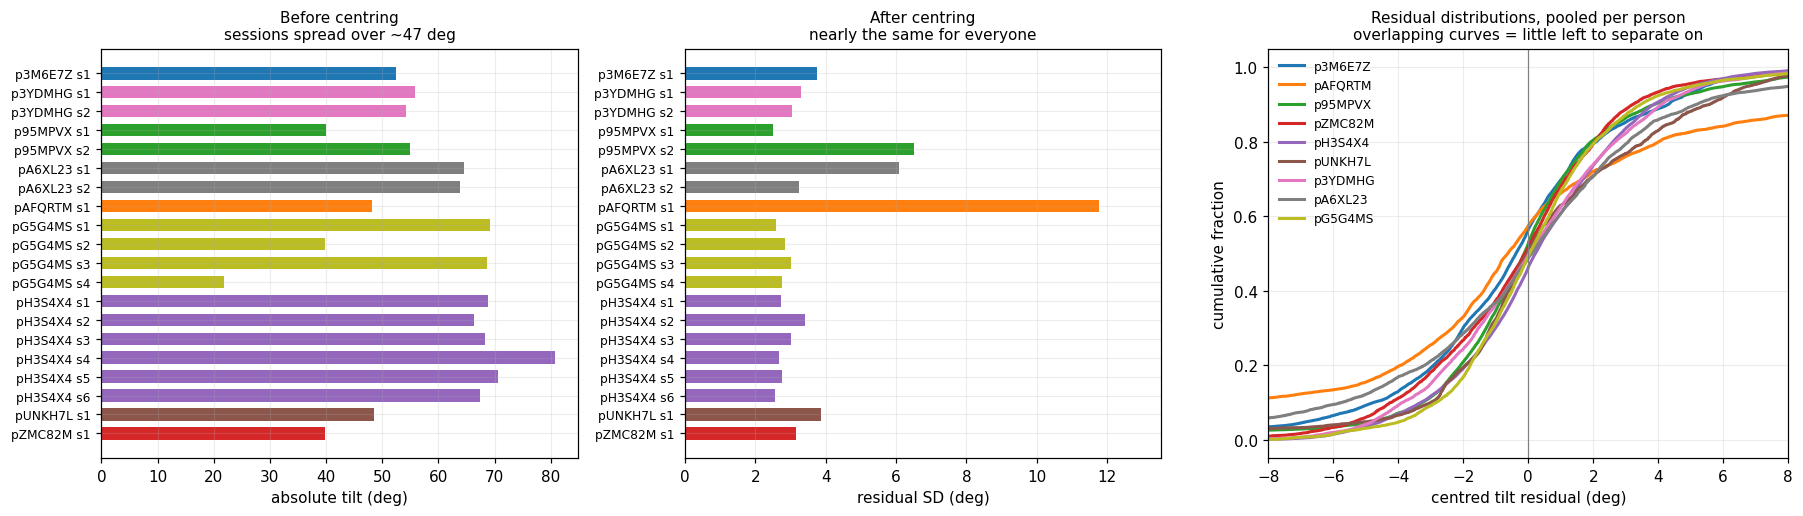

In [12]:
# --- residual after causal centring ---------------------------------------
def residual_frame(raw_df, col='payload_beta', method='rolling'):
    out = []
    for sid, s in raw_df.groupby('sessionId'):
        t, v = orientation_series(s, col)
        if len(v) < MIN_ORIENT:
            continue
        base = causal_baselines(v)[method]
        r = v - base
        ok = np.isfinite(r)
        out.append(pd.DataFrame({'participantId': s['participantId'].iloc[0],
                                 'sessionId': sid, 't_s': t[ok], 'residual': r[ok]}))
    return pd.concat(out, ignore_index=True) if out else pd.DataFrame()


resid_beta = residual_frame(raw, 'payload_beta')
resid_gamma = residual_frame(raw, 'payload_gamma')

_rs = (resid_beta.groupby(['participantId', 'sessionId'])['residual']
       .agg(residual_sd='std',
            residual_iqr=lambda x: float(np.percentile(x, 75) - np.percentile(x, 25)))
       .reset_index())
_rs['session'] = _rs['sessionId'].map(SESSION_LABEL)
_abs = (raw.loc[raw['kind'] == ORIENT_KIND].groupby('sessionId')['payload_beta']
        .apply(lambda s: float(pd.to_numeric(s, errors='coerce').median())))
_rs['absolute_tilt'] = _rs['sessionId'].map(_abs).round(1)
_rs = _rs.sort_values(['participantId', 'session'])

print("Before centring, sessions differ by tens of degrees. After centring, the")
print("residual spread is nearly the same number for everybody.\n")
print(_rs[['session', 'absolute_tilt', 'residual_sd', 'residual_iqr']]
      .round(2).to_string(index=False))
print(f"\nabsolute tilt across sessions : "
      f"{_rs['absolute_tilt'].min():.0f} to {_rs['absolute_tilt'].max():.0f} deg "
      f"(spread {_rs['absolute_tilt'].max() - _rs['absolute_tilt'].min():.0f})")
print(f"residual SD across sessions   : "
      f"{_rs['residual_sd'].min():.2f} to {_rs['residual_sd'].max():.2f} deg "
      f"(spread {_rs['residual_sd'].max() - _rs['residual_sd'].min():.2f})")


def plot_residual_collapse(rs, rb):
    fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.8),
                             gridspec_kw={'width_ratios': [1.1, 1.1, 1.2]})
    ax = axes[0]
    y = np.arange(len(rs))
    ax.barh(y, rs['absolute_tilt'], color=[pcolor(p) for p in rs['participantId']],
            height=0.65)
    ax.set_yticks(y); ax.set_yticklabels(rs['session'], fontsize=8); ax.invert_yaxis()
    ax.set_xlabel("absolute tilt (deg)")
    ax.set_title("Before centring\nsessions spread over ~47 deg", fontsize=10)

    ax = axes[1]
    ax.barh(y, rs['residual_sd'], color=[pcolor(p) for p in rs['participantId']],
            height=0.65)
    ax.set_yticks(y); ax.set_yticklabels(rs['session'], fontsize=8); ax.invert_yaxis()
    ax.set_xlabel("residual SD (deg)")
    ax.set_xlim(0, max(7, rs['residual_sd'].max() * 1.15))
    ax.set_title("After centring\nnearly the same for everyone", fontsize=10)

    ax = axes[2]
    for p in PARTICIPANTS:
        v = rb.loc[rb['participantId'] == p, 'residual'].to_numpy()
        v = v[np.isfinite(v)]
        if len(v) < 500:
            continue
        v = np.sort(v)
        ax.plot(v, np.arange(1, len(v) + 1) / len(v), color=pcolor(p), lw=2, label=p)
    ax.set_xlim(-8, 8); ax.axvline(0, color='0.5', lw=0.8)
    ax.set_xlabel("centred tilt residual (deg)"); ax.set_ylabel("cumulative fraction")
    ax.set_title("Residual distributions, pooled per person\n"
                 "overlapping curves = little left to separate on", fontsize=10)
    ax.legend(fontsize=8, frameon=False)
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_residual_collapse(_rs, resid_beta)

The collapse is the point of the section. Absolute tilt separates sessions across roughly
59 degrees (22° to 81°); the centred residual mostly falls between 2.5° and 3.9°, with
seventeen of the twenty sessions in that band. The residual ECDFs mostly sit on top of one
another, with three visible exceptions.

Two of those three are pA6XL23 s1 and p95MPVX s2, just over 6°, both genuine mid-session
repositions from Section 5.2 — a reminder that the residual still picks up posture
*changes* even after removing posture *level*. The third is pAFQRTM s1 at 11.8°, and this
one is not a coordinate-system artifact: beta genuinely swings from -12° to +186° around
the 7-minute mark of that session (Section 1.1's unwrap fix corrects the plotted spike, but
the underlying minute-long excursion is real and the residual is right to flag it — worth
checking what happened physically at that point in the recording).

That is not a failure — it is the correct result. It says the large, attractive separations
in Sections 2–4 were mostly body position, and body position is a property of the
recording. What is left after removing it is small, and its usefulness has to be argued
rather than assumed.

The next plot puts this side by side with the uncentred version, in the same
window-by-window form used in Section 4, so the two can be compared directly.

3,096 windows with a defined causal baseline (fewer than the 3,119 in Section 4 — the first 5s of each session has no baseline yet)



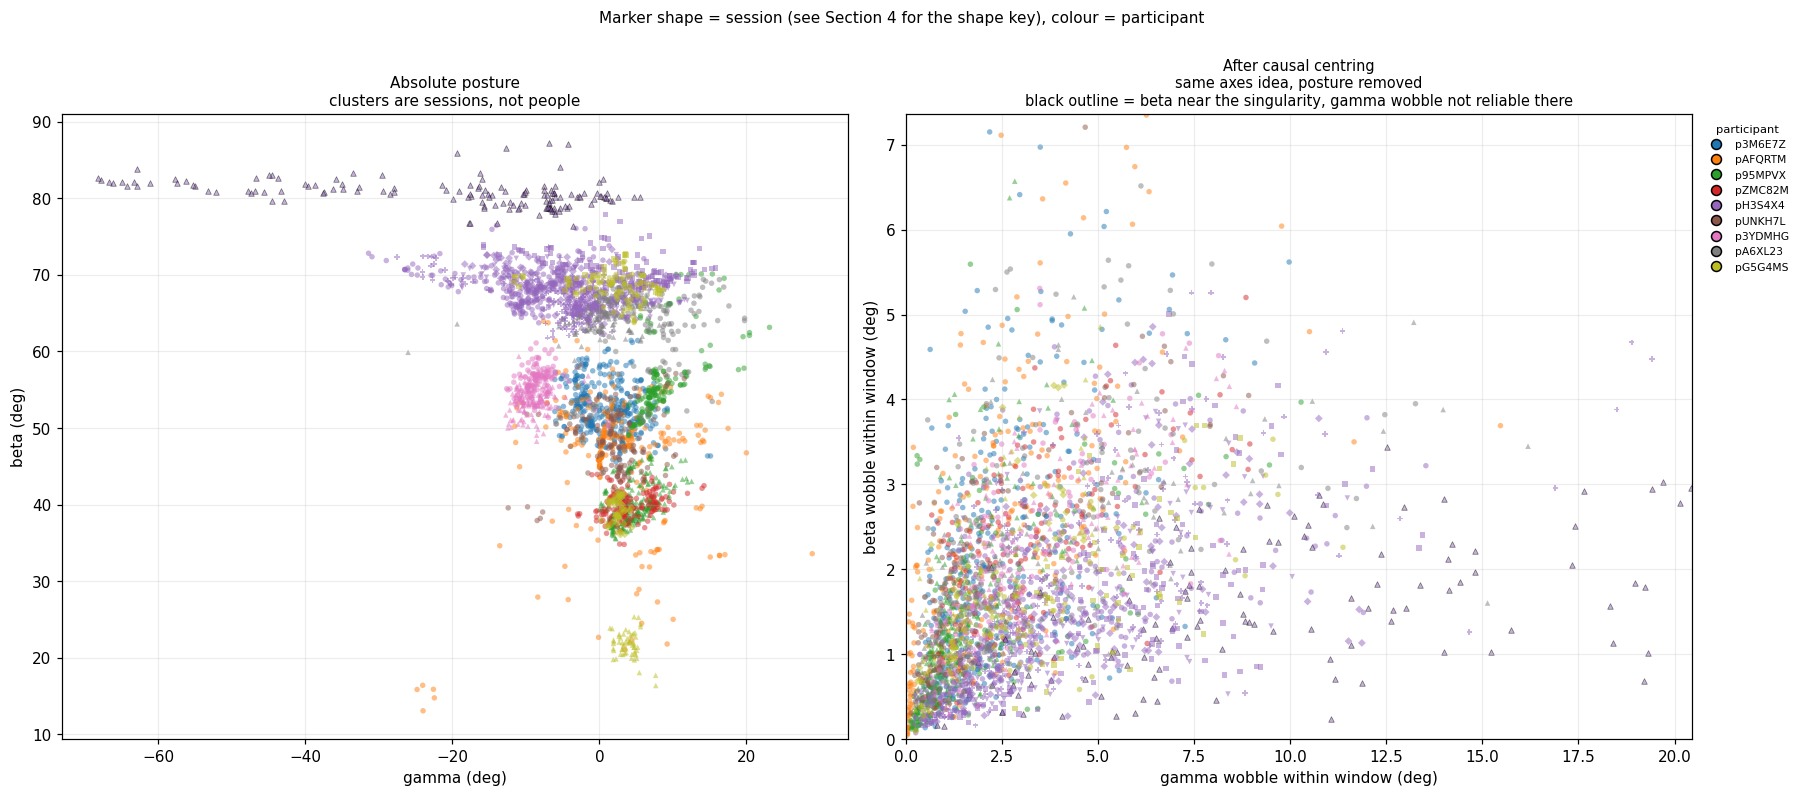

In [13]:
# --- posture space, before and after centring ------------------------------
def build_relative_windows(raw_df, method='rolling'):
    rows = []
    for sid, s in raw_df.groupby('sessionId'):
        tb, vb = orientation_series(s, 'payload_beta')
        tg, vg = orientation_series(s, 'payload_gamma')
        if len(vb) < MIN_ORIENT or len(vg) < MIN_ORIENT:
            continue
        rb = vb - causal_baselines(vb)[method]
        rg = vg - causal_baselines(vg)[method]
        end = s['tRelMs'].max() / 1000.0
        lo = 0.0
        while lo + CA_WINDOW_S <= end:
            mb = (tb >= lo) & (tb < lo + CA_WINDOW_S)
            mg = (tg >= lo) & (tg < lo + CA_WINDOW_S)
            if mb.sum() >= MIN_ORIENT_PER_WINDOW and mg.sum() >= MIN_ORIENT_PER_WINDOW:
                b, g = rb[mb], rg[mg]
                if np.isfinite(b).sum() > 5 and np.isfinite(g).sum() > 5:
                    rows.append({'participantId': s['participantId'].iloc[0],
                                 'sessionId': sid, 'window_start_s': lo,
                                 'beta_wobble': float(np.nanstd(b)),
                                 'gamma_wobble': float(np.nanstd(g)),
                                 'beta_range': float(np.nanmax(b) - np.nanmin(b))})
            lo += CA_STRIDE_S
    return pd.DataFrame(rows)


rel_windows = build_relative_windows(raw)
print(f"{len(rel_windows):,} windows with a defined causal baseline "
      f"(fewer than the {len(windows):,} in Section 4 — the first "
      f"{WARMUP_S:.0f}s of each session has no baseline yet)\n")


def plot_before_after(w_abs, w_rel):
    fig, axes = plt.subplots(1, 2, figsize=(16.5, 7.2))
    singular = {sid: session_singularity(raw.loc[raw['sessionId'] == sid])
                for sid in session_index['sessionId']}

    ax = axes[0]
    for p in PARTICIPANTS:
        d = w_abs.loc[w_abs['participantId'] == p]
        for j, (sid, g) in enumerate(d.groupby('sessionId')):
            is_sing = singular.get(sid, False)
            ax.scatter(g['gamma'], g['beta'], s=13, alpha=0.5, color=pcolor(p),
                       marker=SESSION_MARKERS[j % len(SESSION_MARKERS)],
                       edgecolor='k' if is_sing else 'none', linewidth=0.5 if is_sing else 0)
    ax.set_xlabel("gamma (deg)"); ax.set_ylabel("beta (deg)")
    ax.set_title("Absolute posture\nclusters are sessions, not people", fontsize=10)

    ax = axes[1]
    for p in PARTICIPANTS:
        d = w_rel.loc[w_rel['participantId'] == p]
        for j, (sid, g) in enumerate(d.groupby('sessionId')):
            is_sing = singular.get(sid, False)
            ax.scatter(g['gamma_wobble'], g['beta_wobble'], s=13, alpha=0.5,
                       color=pcolor(p), marker=SESSION_MARKERS[j % len(SESSION_MARKERS)],
                       edgecolor='k' if is_sing else 'none', linewidth=0.5 if is_sing else 0)
    ax.set_xlabel("gamma wobble within window (deg)")
    ax.set_ylabel("beta wobble within window (deg)")
    ax.set_title("After causal centring\nsame axes idea, posture removed\n"
                 "black outline = beta near the singularity, gamma wobble not reliable there",
                 fontsize=9.5)
    ax.set_xlim(0, np.nanpercentile(w_rel['gamma_wobble'], 99))
    ax.set_ylim(0, np.nanpercentile(w_rel['beta_wobble'], 99))
    colour_handles = [Line2D([0], [0], marker='o', color='none', markerfacecolor=pcolor(p),
                             markersize=6.5, label=p) for p in PARTICIPANTS]
    ax.legend(handles=colour_handles, bbox_to_anchor=(1.005, 1), loc='upper left',
              frameon=False, fontsize=7, title='participant', title_fontsize=7.5)
    fig.suptitle("Marker shape = session (see Section 4 for the shape key), "
                 "colour = participant", y=1.0, fontsize=10)
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_before_after(windows, rel_windows)

The left panel is Section 4's plot: tidy, well-separated clusters that are mostly sessions.
The right panel is the same participants once posture has been subtracted, plotted in terms
of how much the phone moves within each window rather than where it is held.

The clusters merge. Whatever is still distinguishing people on the right is doing so on a
much smaller margin than the left panel promised — and that margin is the honest one,
because it is the only part that does not depend on where somebody happened to be sitting.

### 6.1 The baseline's own movement is also a feature

Subtracting a baseline produces two things, not one: the residual, and the path the
baseline itself took. The residual is fast hand movement. The baseline's drift is slow
re-settling — the gradual slump or shift over tens of seconds.

Section 9 already measures the second of these, under the name "slow repositioning". It
was a rolling-baseline drift rate all along.

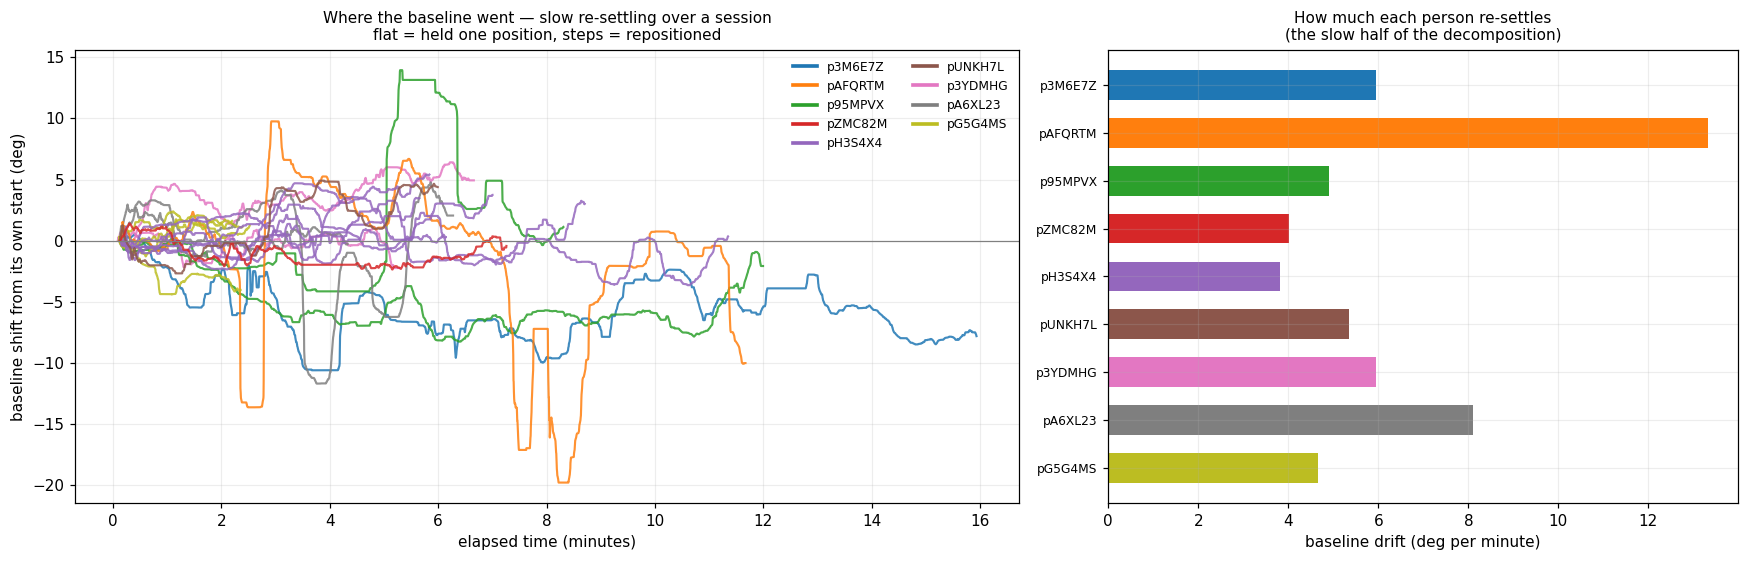

   session  total_path_deg  drift_deg_per_min  net_change_deg
p3M6E7Z s1           93.76               5.95           -7.83
p3YDMHG s1           33.10               6.38           -2.25
p3YDMHG s2           35.96               5.53            4.93
p95MPVX s1           43.63               3.68           -2.08
p95MPVX s2           50.07               6.15            1.12
pA6XL23 s1           61.97              10.07            2.05
pA6XL23 s2           25.83               6.14           -0.28
pAFQRTM s1          153.61              13.32          -10.03
pG5G4MS s1            9.95               4.38            1.13
pG5G4MS s2            9.43               4.54            1.61
pG5G4MS s3           10.01               4.46           -4.04
pG5G4MS s4           12.79               5.30            1.24
pH3S4X4 s1           50.09               4.49            0.34
pH3S4X4 s2           36.72               4.29            3.00
pH3S4X4 s3           31.12               4.59            3.74
pH3S4X4 

In [14]:
# --- the baseline path itself ---------------------------------------------
def plot_baseline_paths(raw_df):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5.2),
                             gridspec_kw={'width_ratios': [1.5, 1]})
    ax = axes[0]
    drift_rows = []
    for sid in SESSION_ORDER:
        s = raw_df.loc[raw_df['sessionId'] == sid]
        t, v = orientation_series(s)
        if len(v) < MIN_ORIENT:
            continue
        p = s['participantId'].iloc[0]
        base = causal_baselines(v)['rolling']
        ok = np.isfinite(base)
        if ok.sum() < 100:
            continue
        # centre each baseline on its own start so the shapes can be compared
        ax.plot(t[ok] / 60.0, base[ok] - base[ok][0], color=pcolor(p), lw=1.4, alpha=0.85)
        dur_min = (t[ok][-1] - t[ok][0]) / 60.0
        drift_rows.append({'participantId': p, 'sessionId': sid,
                           'total_path_deg': float(np.abs(np.diff(base[ok])).sum()),
                           'drift_deg_per_min': float(np.abs(np.diff(base[ok])).sum()
                                                      / max(dur_min, 1e-6)),
                           'net_change_deg': float(base[ok][-1] - base[ok][0])})
    ax.axhline(0, color='0.5', lw=0.8)
    ax.set_xlabel("elapsed time (minutes)")
    ax.set_ylabel("baseline shift from its own start (deg)")
    ax.set_title("Where the baseline went — slow re-settling over a session\n"
                 "flat = held one position, steps = repositioned", fontsize=10)
    handles = [Line2D([0], [0], color=pcolor(p), lw=2.4, label=p) for p in PARTICIPANTS]
    ax.legend(handles=handles, fontsize=8, frameon=False, ncol=2)

    drift = pd.DataFrame(drift_rows)
    ax = axes[1]
    per_p = drift.groupby('participantId')['drift_deg_per_min'].mean().reindex(PARTICIPANTS)
    ax.barh(np.arange(len(per_p)), per_p.values,
            color=[pcolor(p) for p in per_p.index], height=0.62)
    ax.set_yticks(np.arange(len(per_p))); ax.set_yticklabels(per_p.index, fontsize=8)
    ax.invert_yaxis(); ax.set_xlabel("baseline drift (deg per minute)")
    ax.set_title("How much each person re-settles\n(the slow half of the decomposition)",
                 fontsize=10)
    plt.tight_layout(); plt.show(); plt.close(fig)
    return drift


baseline_drift = plot_baseline_paths(raw)
print(baseline_drift.assign(session=lambda d: d['sessionId'].map(SESSION_LABEL))
      [['session', 'total_path_deg', 'drift_deg_per_min', 'net_change_deg']]
      .round(2).to_string(index=False))

Read the left panel as shape rather than level. A flat line is somebody who found a
position and stayed in it; a line with a step in it is somebody who moved partway through;
a line that wanders continuously is somebody who never quite settles.

With one or two sessions for most participants this is a description, not a trait — the
same person might settle quickly one day and not the next, and there is no way to tell
from this cohort. It goes on the list of things a larger dataset would resolve.

## 7. Movement — what "holding still" looks like

Switching from attitude to motion. `ax/ay/az` have gravity removed, so they measure
movement rather than orientation.

A phone in a hand is never truly still; a phone on a table is. That gives a way to tell
the two apart: look at acceleration during moments when nobody is touching the screen. If
the low tail of that distribution approaches zero, something other than a hand was holding
the device.

"Idle" here means no interaction within a second either side.

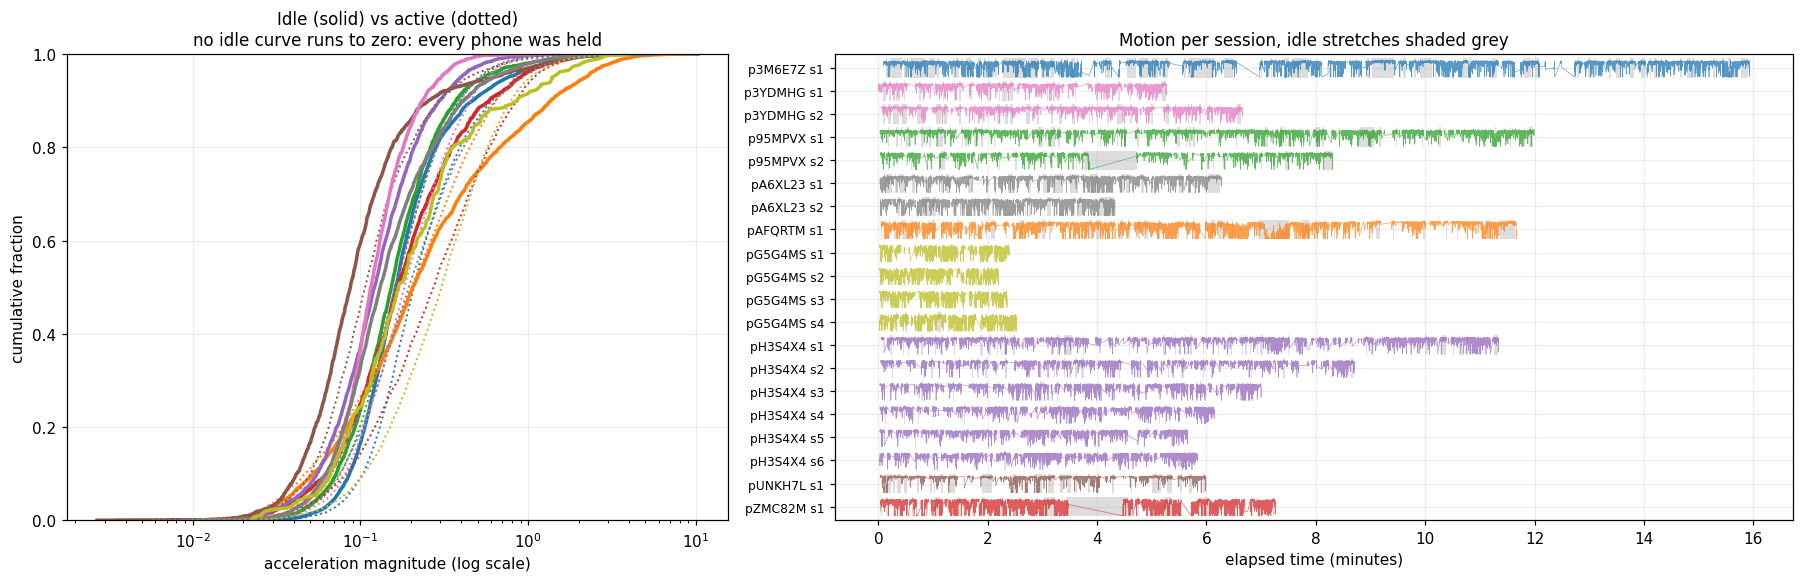

In [15]:
IDLE_GUARD_MS = 1000.0


def idle_mask(sess, motion_t_ms):
    inter = np.sort(sess.loc[sess['kind'].isin(INTERACTION_KINDS), 'tRelMs'].to_numpy(float))
    if len(inter) == 0:
        return np.ones(len(motion_t_ms), bool)
    idx = np.searchsorted(inter, motion_t_ms)
    prev_gap = np.where(idx > 0, motion_t_ms - inter[np.clip(idx - 1, 0, len(inter) - 1)], np.inf)
    next_gap = np.where(idx < len(inter), inter[np.clip(idx, 0, len(inter) - 1)] - motion_t_ms, np.inf)
    return (prev_gap >= IDLE_GUARD_MS) & (next_gap >= IDLE_GUARD_MS)


def motion_arrays(sess):
    m = sess.loc[sess['kind'] == MOTION_KIND].sort_values('tRelMs')
    t = m['tRelMs'].to_numpy(float)
    mag = np.sqrt(sum(pd.to_numeric(m[c], errors='coerce').to_numpy(float) ** 2
                      for c in ACCEL_COLS))
    ok = np.isfinite(mag)
    return t[ok], mag[ok]


def plot_motion(raw_df):
    fig, axes = plt.subplots(1, 2, figsize=(16.5, 5.4), gridspec_kw={'width_ratios': [1, 1.45]})
    ax = axes[0]
    for p in PARTICIPANTS:
        idle_v, act_v = [], []
        for sid, s in raw_df.loc[raw_df['participantId'] == p].groupby('sessionId'):
            t, mag = motion_arrays(s)
            if len(t) < 100:
                continue
            im = idle_mask(s, t)
            idle_v.append(mag[im]); act_v.append(mag[~im])
        for arr, ls, lw in ((idle_v, '-', 2.3), (act_v, ':', 1.3)):
            arr = [a for a in arr if len(a)]
            if not arr:
                continue
            v = np.concatenate(arr); v = v[v > 0]
            if len(v) < 50:
                continue
            ax.plot(np.sort(v), np.arange(1, len(v) + 1) / len(v), color=pcolor(p), ls=ls, lw=lw)
    ax.set_xscale('log'); ax.set_ylim(0, 1)
    ax.set_xlabel("acceleration magnitude (log scale)"); ax.set_ylabel("cumulative fraction")
    ax.set_title("Idle (solid) vs active (dotted)\nno idle curve runs to zero: every phone was held")

    ax = axes[1]
    for row, sid in enumerate(SESSION_ORDER):
        s = raw_df.loc[raw_df['sessionId'] == sid]
        t, mag = motion_arrays(s)
        if len(t) < 100:
            continue
        im = idle_mask(s, t)
        change = np.where(np.diff(im.astype(int)) != 0)[0] + 1
        for run in np.split(np.arange(len(t)), change):
            if len(run) < 10 or not im[run[0]]:
                continue
            ax.fill_between([t[run[0]] / 60000.0, t[run[-1]] / 60000.0],
                            row - 0.42, row + 0.42, color='0.78', alpha=0.6, lw=0, zorder=0)
        ax.plot(t / 60000.0, row + np.clip(mag, 0, 1.0) * 0.75 - 0.35,
                color=pcolor(s['participantId'].iloc[0]), lw=0.4, alpha=0.75,
                rasterized=True, zorder=2)
    ax.set_yticks(range(len(SESSION_ORDER)))
    ax.set_yticklabels([SESSION_LABEL.get(x, x[:6]) for x in SESSION_ORDER], fontsize=8)
    ax.set_ylim(len(SESSION_ORDER) - 0.4, -0.6)
    ax.set_xlabel("elapsed time (minutes)")
    ax.set_title("Motion per session, idle stretches shaded grey")
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_motion(raw)

## 8. Who can be measured, and who cannot

Everything in the next two sections needs the person to stop touching the screen for a
few seconds. That is not equally available.

This is a real property of the data rather than a technicality: the participant who never
pauses cannot be described by any idle-based measure, and their absence from those plots
is itself informative about them.

               idle_epochs  idle_seconds  longest_idle_s  session_minutes  idle_pct_of_session
participantId                                                                                 
p3M6E7Z                 32         281.2            29.0             15.9                 29.5
pAFQRTM                 13         102.4            34.4             11.7                 14.6
p95MPVX                 13         126.4            58.3             20.3                 10.4
pZMC82M                  8         109.3            68.6              7.3                 25.0
pH3S4X4                  6          27.7             9.3             44.7                  1.0
pUNKH7L                 12          69.9            11.0              6.0                 19.4
p3YDMHG                 13          59.7             6.5             11.9                  8.4
pA6XL23                 17         113.8            15.6             10.6                 17.9
pG5G4MS                  1           3.6          

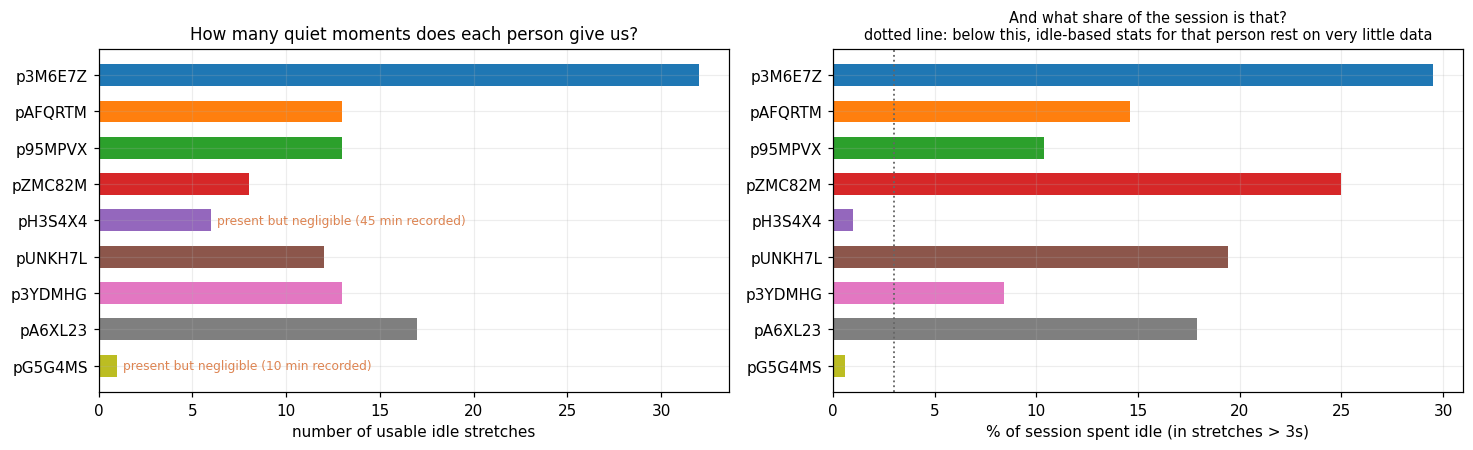

In [16]:
MIN_IDLE_RUN = 60      # samples, roughly 3 s at the observed rate


def idle_runs(raw_df):
    rows = []
    for sid, s in raw_df.groupby('sessionId'):
        t, mag = motion_arrays(s)
        if len(t) < 100:
            continue
        im = idle_mask(s, t)
        change = np.where(np.diff(im.astype(int)) != 0)[0] + 1
        for run in np.split(np.arange(len(t)), change):
            if len(run) < MIN_IDLE_RUN or not im[run[0]]:
                continue
            rows.append({'participantId': s['participantId'].iloc[0], 'sessionId': sid,
                         'start_s': t[run[0]] / 1000.0,
                         'duration_s': (t[run[-1]] - t[run[0]]) / 1000.0,
                         'idx0': run[0], 'idx1': run[-1]})
    return pd.DataFrame(rows)


runs = idle_runs(raw)
avail = (runs.groupby('participantId')
         .agg(idle_epochs=('duration_s', 'size'), idle_seconds=('duration_s', 'sum'),
              longest_idle_s=('duration_s', 'max'))
         .reindex(PARTICIPANTS).fillna(0))
avail['session_minutes'] = (session_index.groupby('participantId')['duration_s'].sum()
                            .reindex(PARTICIPANTS) / 60).round(1)
avail['idle_pct_of_session'] = (avail['idle_seconds'] /
                                (avail['session_minutes'] * 60) * 100).round(1)


LOW_SUPPORT_PCT = 3.0  # % of session idle, below which a per-idle-window stat is fragile


def plot_availability(av):
    fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.2))
    ax = axes[0]
    y = np.arange(len(av))
    ax.barh(y, av['idle_epochs'], color=[pcolor(p) for p in av.index], height=0.6)
    ax.set_yticks(y); ax.set_yticklabels(av.index); ax.invert_yaxis()
    ax.set_xlabel("number of usable idle stretches")
    ax.set_title("How many quiet moments does each person give us?")
    for i, p in enumerate(av.index):
        if av.loc[p, 'idle_epochs'] == 0:
            ax.text(0.2, i, "none — cannot be measured", va='center', fontsize=9, color='#c44e52')
        elif av.loc[p, 'idle_pct_of_session'] < LOW_SUPPORT_PCT:
            mins = av.loc[p, 'session_minutes']
            ax.text(av.loc[p, 'idle_epochs'] + 0.3, i,
                    f"present but negligible ({mins:.0f} min recorded)",
                    va='center', fontsize=8, color='#dd8452')
    ax = axes[1]
    ax.barh(y, av['idle_pct_of_session'], color=[pcolor(p) for p in av.index], height=0.6)
    ax.set_yticks(y); ax.set_yticklabels(av.index); ax.invert_yaxis()
    ax.axvline(LOW_SUPPORT_PCT, color='0.4', ls=':', lw=1.2)
    ax.set_xlabel("% of session spent idle (in stretches > 3s)")
    ax.set_title("And what share of the session is that?\ndotted line: below this, idle-based "
                 "stats for that person rest on very little data", fontsize=9.5)
    plt.tight_layout(); plt.show(); plt.close(fig)


print(avail.astype({'idle_epochs': int}).round(1).to_string())
print()
_low = avail.loc[(avail['idle_epochs'] > 0) & (avail['idle_pct_of_session'] < LOW_SUPPORT_PCT)]
if len(_low):
    print(f"present but low support (< {LOW_SUPPORT_PCT:.0f}% idle despite having sessions): "
          f"{', '.join(_low.index)} — treat any idle-based statistic for these as fragile,")
    print("distinct from participants with zero idle epochs, who cannot be measured at all.")
plot_availability(avail)

## 9. Restlessness while not interacting

If the phone moves while nobody is touching it, that movement came from the person holding
it — small shifts of grip, hand, or posture. Total angular travel per second during idle
stretches is a plain measure of that.

Two things make this interesting and one makes it awkward.

It is a different quantity from anything else measured in this project: not speed, not
accuracy, not gesture shape, but how much someone moves while doing nothing. And it does
not track session pace, so it is not another way of measuring how fast someone works.

The awkwardness is that it is only defined for people who pause, which excludes the
participant who never does.

115 idle stretches usable, covering 9/9 participants

               angular_travel_deg_s  beta_wander_deg  net_drift_deg
participantId                                                      
p3M6E7Z                        7.03             6.75           1.46
pAFQRTM                        4.99             4.79           2.44
p95MPVX                        4.37             4.77           3.44
pZMC82M                       10.27             6.85           2.52
pH3S4X4                        9.94             4.33           1.46
pUNKH7L                        3.45             4.99           2.17
p3YDMHG                        4.91             3.86           1.71
pA6XL23                        7.17             5.65           1.92
pG5G4MS                        4.11             2.31           1.72


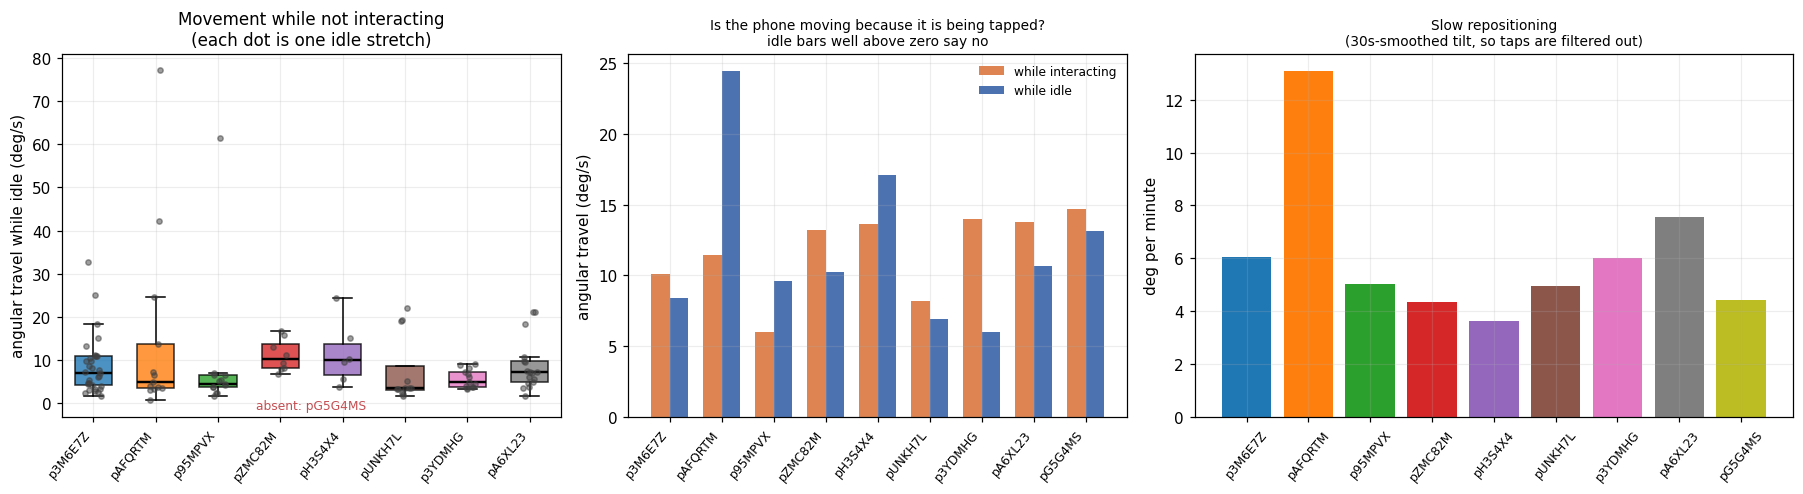

In [17]:
def idle_dynamics(raw_df):
    rows = []
    for sid, s in raw_df.groupby('sessionId'):
        o = s.loc[s['kind'] == ORIENT_KIND].sort_values('tRelMs')
        ot = o['tRelMs'].to_numpy(float)
        beta = pd.to_numeric(o['payload_beta'], errors='coerce').to_numpy(float)
        gamma = pd.to_numeric(o['payload_gamma'], errors='coerce').to_numpy(float)
        ok = np.isfinite(beta) & np.isfinite(gamma)
        ot, beta, gamma = ot[ok], beta[ok], gamma[ok]
        if len(ot) < MIN_ORIENT:
            continue
        for r in runs.loc[runs['sessionId'] == sid].itertuples():
            t0, t1 = r.start_s * 1000, (r.start_s + r.duration_s) * 1000
            m = (ot >= t0) & (ot <= t1)
            if m.sum() < 30:
                continue
            dt = np.diff(ot[m]) / 1000.0
            travel = np.abs(np.diff(beta[m])) + np.abs(np.diff(gamma[m]))
            good = (dt > 0) & (dt < 0.5)
            if good.sum() < 20:
                continue
            rows.append({'participantId': r.participantId, 'sessionId': sid,
                         'duration_s': r.duration_s,
                         'angular_travel_deg_s': float(travel[good].sum() / dt[good].sum()),
                         'beta_wander_deg': float(np.ptp(beta[m])),
                         'net_drift_deg': float(abs(beta[m][-1] - beta[m][0]))})
    return pd.DataFrame(rows)


idle_dyn = idle_dynamics(raw)


def plot_restlessness(dyn, raw_df):
    fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.6),
                             gridspec_kw={'width_ratios': [1, 1, 1.2]})
    ax = axes[0]
    data, names, colors = [], [], []
    for p in PARTICIPANTS:
        v = dyn.loc[dyn['participantId'] == p, 'angular_travel_deg_s'].dropna().to_numpy()
        if len(v) < 3:
            continue
        data.append(v); names.append(p); colors.append(pcolor(p))
    missing = [p for p in PARTICIPANTS if p not in names]
    if data:
        bp = ax.boxplot(data, patch_artist=True, showfliers=False, widths=0.6,
                        medianprops={'color': 'black', 'lw': 1.6})
        for patch, c in zip(bp['boxes'], colors):
            patch.set_facecolor(c); patch.set_alpha(0.8)
        for i, v in enumerate(data):
            ax.scatter(np.full(len(v), i + 1) + np.random.uniform(-0.13, 0.13, len(v)),
                       v, s=12, color='0.25', alpha=0.5, zorder=3)
        ax.set_xticks(range(1, len(names) + 1))
        ax.set_xticklabels(names, rotation=50, ha='right', fontsize=8)
    ax.set_ylabel("angular travel while idle (deg/s)")
    ax.set_title("Movement while not interacting\n(each dot is one idle stretch)")
    if missing:
        ax.text(0.5, 0.02, f"absent: {', '.join(missing)}", transform=ax.transAxes,
                ha='center', fontsize=8, color='#c44e52')

    # is it just interaction? compare active vs idle travel
    ax = axes[1]
    comp = []
    for p in PARTICIPANTS:
        act, idl = [], []
        for sid, s in raw_df.loc[raw_df['participantId'] == p].groupby('sessionId'):
            o = s.loc[s['kind'] == ORIENT_KIND].sort_values('tRelMs')
            ot = o['tRelMs'].to_numpy(float)
            b = pd.to_numeric(o['payload_beta'], errors='coerce').to_numpy(float)
            g = pd.to_numeric(o['payload_gamma'], errors='coerce').to_numpy(float)
            ok = np.isfinite(b) & np.isfinite(g); ot, b, g = ot[ok], b[ok], g[ok]
            if len(ot) < MIN_ORIENT:
                continue
            im = idle_mask(s, ot)
            dt = np.diff(ot) / 1000.0
            travel = np.abs(np.diff(b)) + np.abs(np.diff(g))
            good = (dt > 0) & (dt < 0.5)
            ma, mi = (~im[:-1]) & good, im[:-1] & good
            if ma.sum() > 20:
                act.append(travel[ma].sum() / dt[ma].sum())
            if mi.sum() > 20:
                idl.append(travel[mi].sum() / dt[mi].sum())
        comp.append({'participantId': p,
                     'active': np.mean(act) if act else np.nan,
                     'idle': np.mean(idl) if idl else np.nan})
    comp = pd.DataFrame(comp).set_index('participantId')
    x = np.arange(len(comp)); w = 0.36
    ax.bar(x - w / 2, comp['active'], width=w, label='while interacting', color='#dd8452')
    ax.bar(x + w / 2, comp['idle'], width=w, label='while idle', color='#4c72b0')
    ax.set_xticks(x); ax.set_xticklabels(comp.index, rotation=50, ha='right', fontsize=8)
    ax.set_ylabel("angular travel (deg/s)")
    ax.set_title("Is the phone moving because it is being tapped?\n"
                 "idle bars well above zero say no", fontsize=9)
    ax.legend(frameon=False, fontsize=8)

    # slow repositioning
    ax = axes[2]
    for p in PARTICIPANTS:
        tot = []
        for sid, s in raw_df.loc[raw_df['participantId'] == p].groupby('sessionId'):
            o = s.loc[s['kind'] == ORIENT_KIND].sort_values('tRelMs')
            t = o['tRelMs'].to_numpy(float) / 1000.0
            b = pd.to_numeric(o['payload_beta'], errors='coerce').to_numpy(float)
            ok = np.isfinite(b); t, b = t[ok], b[ok]
            if len(t) < 600:
                continue
            sm = pd.Series(b).rolling(600, min_periods=200, center=True).median().to_numpy()
            v = np.isfinite(sm)
            tot.append(float(np.abs(np.diff(sm[v])).sum() / ((t.max() - t.min()) / 60)))
        if tot:
            ax.bar(p, np.mean(tot), color=pcolor(p))
    ax.set_ylabel("deg per minute")
    ax.tick_params(axis='x', rotation=50, labelsize=8)
    ax.set_title("Slow repositioning\n(30s-smoothed tilt, so taps are filtered out)", fontsize=9)
    plt.tight_layout(); plt.show(); plt.close(fig)


print(f"{len(idle_dyn)} idle stretches usable, covering "
      f"{idle_dyn['participantId'].nunique()}/{len(PARTICIPANTS)} participants\n")
if len(idle_dyn):
    print(idle_dyn.groupby('participantId')[['angular_travel_deg_s', 'beta_wander_deg',
                                             'net_drift_deg']]
          .median().reindex(PARTICIPANTS).round(2).to_string())
plot_restlessness(idle_dyn, raw)

## 10. Frequency content of idle motion

The same idle stretches, viewed as spectra rather than totals. This separates *slow*
movement (drifting posture, a hand settling) from *fast* movement (fine wobble).

Read the shape, not the absolute level, and remember Section 1.1: the right-hand end of
each curve is at or past the sampling limit, so energy there is partly folded down from
frequencies the sensor could never see. The useful comparison is whether one person's
curve is consistently steeper or flatter than another's.

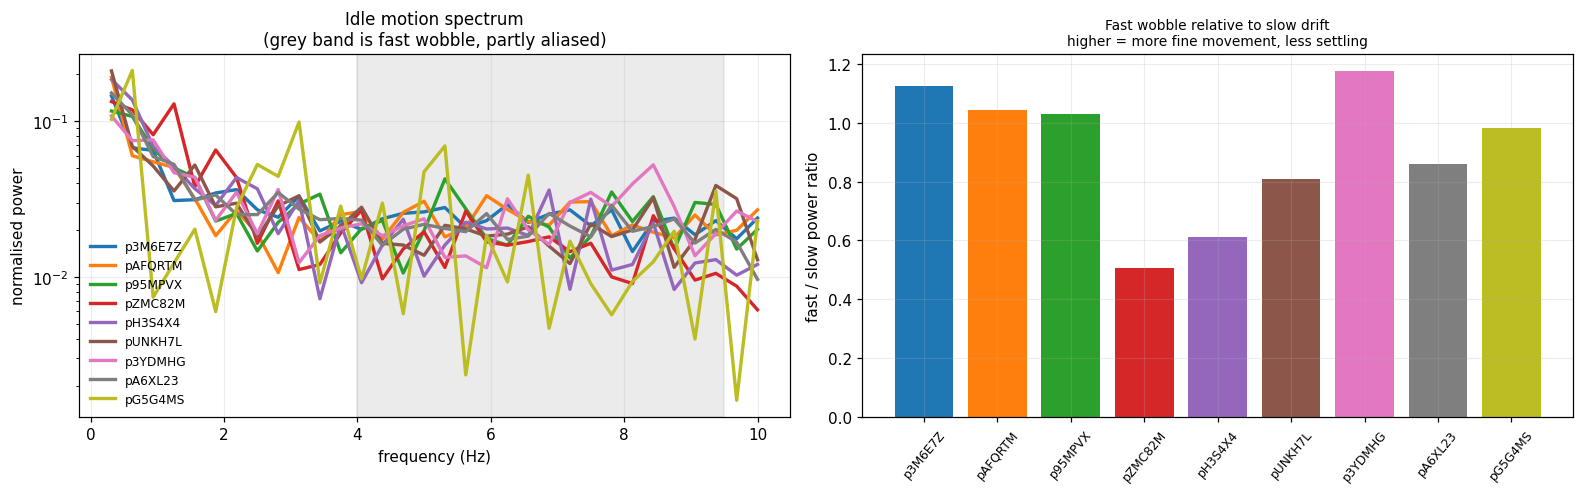

In [18]:
def idle_spectra(raw_df, n_fft=64):
    out = {}
    for p in PARTICIPANTS:
        spec = []
        for sid, s in raw_df.loc[raw_df['participantId'] == p].groupby('sessionId'):
            t, mag = motion_arrays(s)
            if len(t) < 100:
                continue
            im = idle_mask(s, t)
            change = np.where(np.diff(im.astype(int)) != 0)[0] + 1
            for run in np.split(np.arange(len(t)), change):
                if len(run) < n_fft or not im[run[0]]:
                    continue
                x = mag[run][:n_fft]
                x = x - x.mean()
                pw = np.abs(np.fft.rfft(x)) ** 2
                tot = pw[1:].sum()
                if tot > 0:
                    spec.append(pw / tot)
        if spec:
            out[p] = np.mean(spec, axis=0)
    freqs = np.fft.rfftfreq(n_fft, d=1.0 / SAMPLE_HZ)
    return freqs, out


def plot_spectra(raw_df):
    freqs, spec = idle_spectra(raw_df)
    fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.6))
    ax = axes[0]
    for p, pw in spec.items():
        ax.plot(freqs[1:], pw[1:], color=pcolor(p), lw=2.2, label=p)
    ax.axvspan(4, min(9.5, NYQUIST_HZ), color='0.75', alpha=0.3, zorder=0)
    ax.set_yscale('log'); ax.set_xlabel("frequency (Hz)"); ax.set_ylabel("normalised power")
    ax.set_title("Idle motion spectrum\n(grey band is fast wobble, partly aliased)")
    ax.legend(frameon=False, fontsize=8)

    ax = axes[1]
    lo = (freqs > 0) & (freqs <= 2)
    hi = (freqs >= 4) & (freqs <= min(9.5, NYQUIST_HZ))
    names, ratios, colors = [], [], []
    for p, pw in spec.items():
        names.append(p); colors.append(pcolor(p))
        ratios.append(pw[hi].sum() / pw[lo].sum() if pw[lo].sum() > 0 else np.nan)
    ax.bar(names, ratios, color=colors)
    ax.set_ylabel("fast / slow power ratio")
    ax.tick_params(axis='x', rotation=50, labelsize=8)
    ax.set_title("Fast wobble relative to slow drift\nhigher = more fine movement, "
                 "less settling", fontsize=9)
    missing = [p for p in PARTICIPANTS if p not in spec]
    if missing:
        ax.text(0.5, 0.95, f"absent: {', '.join(missing)}", transform=ax.transAxes,
                ha='center', va='top', fontsize=8, color='#c44e52')
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_spectra(raw)

## 11. The alpha wrap

`alpha` is a compass heading, so it runs 0–360 and jumps between the two ends whenever the
phone passes north. Averaging it arithmetically is wrong in a way that is easy to miss: a
device oscillating around north gives readings near 0 and near 360, and their arithmetic
mean is 180 — pointing the opposite way.

The correct treatment is to convert to a unit vector, average that, and convert back. The
polar plots below show both answers on the same dial.

Alpha also describes the room rather than the person — which way they happened to be
facing — so it is not obviously useful as behaviour. It is here because the wrap is a
general trap that applies to any circular quantity, and this is a clear demonstration
of it.

   session     n  wraps  naive_mean  circular_mean  error_deg
p3M6E7Z s1 14278    137       263.4          354.5       91.1
p3YDMHG s1  4656     66       221.4          359.1      137.7
p3YDMHG s2  6012    117       124.1            2.4      121.7
p95MPVX s1 10174    127       139.6            3.6      135.9
p95MPVX s2  5461     10       332.6          351.6       19.0
pA6XL23 s1  5406     91       117.0            5.0      112.0
pA6XL23 s2  3826     66       335.7          353.4       17.7
pAFQRTM s1 10516    166       184.8            0.7      175.9
pG5G4MS s1  1809     47       269.5          354.6       85.2
pG5G4MS s2  1818     24       313.6          357.4       43.8
pG5G4MS s3  1936     52       316.5          356.1       39.6
pG5G4MS s4  2168     20       319.0          356.4       37.4
pH3S4X4 s1  8656    107        42.3            8.0       34.2
pH3S4X4 s2  5641    120       123.2            5.7      117.5
pH3S4X4 s3  4519     74       102.5            7.0       95.5
pH3S4X4 

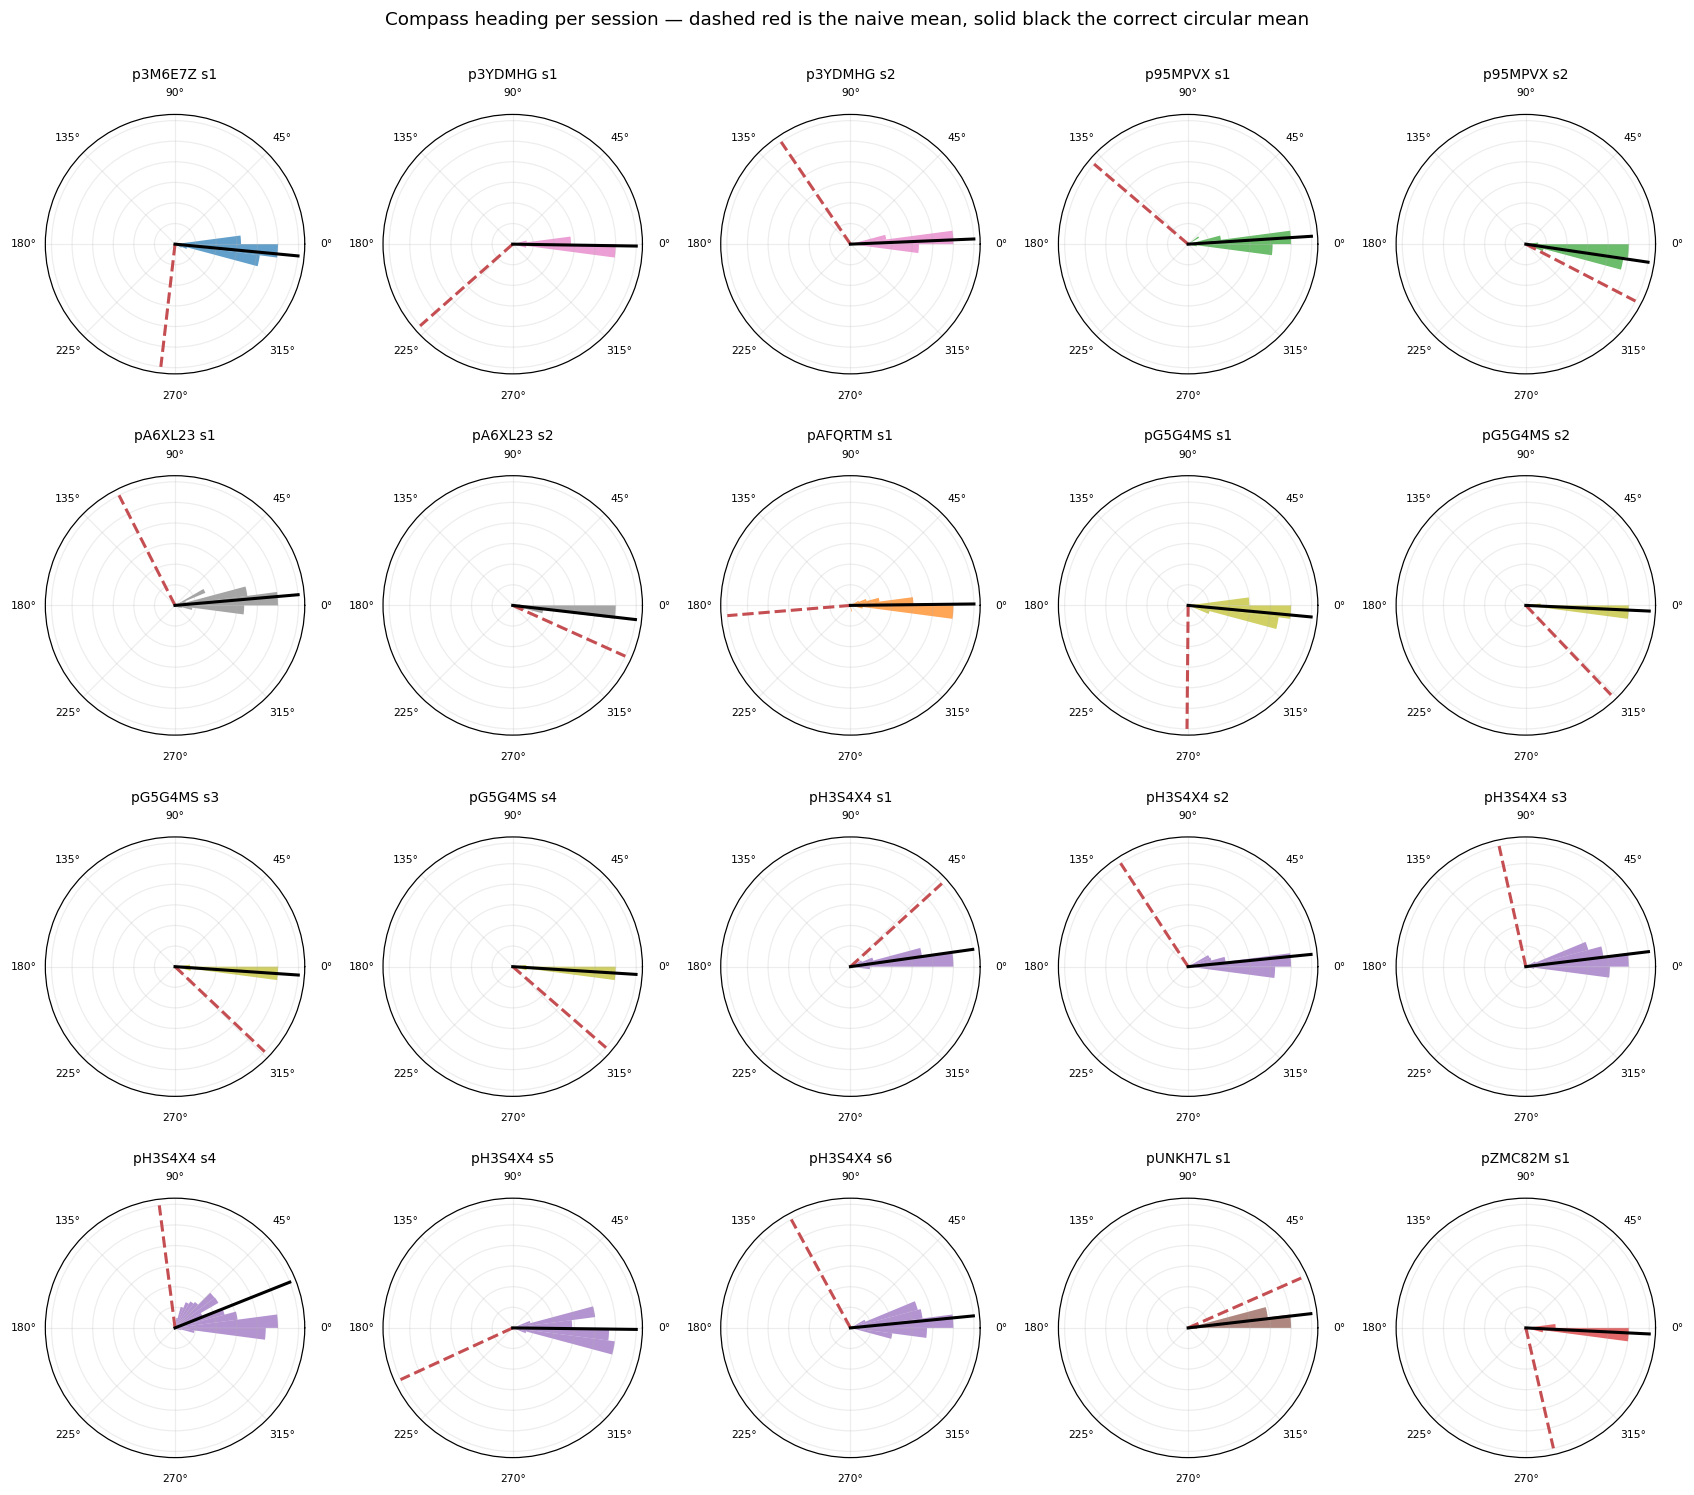

In [19]:
def wrap_table(raw_df):
    rows = []
    for sid in SESSION_ORDER:
        s = raw_df.loc[raw_df['sessionId'] == sid]
        a = pd.to_numeric(s.loc[s['kind'] == ORIENT_KIND, 'payload_alpha'],
                          errors='coerce').dropna().to_numpy()
        if len(a) < 100:
            continue
        ar = np.radians(a)
        circ = float((np.degrees(np.arctan2(np.mean(np.sin(ar)), np.mean(np.cos(ar)))) + 360) % 360)
        naive = float(np.mean(a))
        err = abs(naive - circ)
        rows.append({'session': SESSION_LABEL.get(sid, sid[:8]), 'sessionId': sid, 'n': len(a),
                     'wraps': int((np.abs(np.diff(a)) > 180).sum()),
                     'naive_mean': round(naive, 1), 'circular_mean': round(circ, 1),
                     'error_deg': round(min(err, 360 - err), 1)})
    return pd.DataFrame(rows)


wraps = wrap_table(raw)


def plot_alpha(raw_df, wraps_df):
    sids = wraps_df['sessionId'].tolist()
    ncols = min(5, len(sids)); nrows = int(np.ceil(len(sids) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.1 * ncols, 3.4 * nrows),
                             subplot_kw={'projection': 'polar'}, squeeze=False)
    for ax, sid in zip(axes.ravel(), sids):
        s = raw_df.loc[raw_df['sessionId'] == sid]
        a = pd.to_numeric(s.loc[s['kind'] == ORIENT_KIND, 'payload_alpha'],
                          errors='coerce').dropna().to_numpy()
        ar = np.radians(a)
        counts, edges = np.histogram(ar, bins=48, range=(0, 2 * np.pi))
        ax.bar((edges[:-1] + edges[1:]) / 2, counts / max(counts.max(), 1),
               width=2 * np.pi / 48, color=pcolor(s['participantId'].iloc[0]), alpha=0.7)
        naive = np.radians(np.mean(a))
        circ = np.arctan2(np.mean(np.sin(ar)), np.mean(np.cos(ar)))
        ax.plot([naive, naive], [0, 1.2], color='#c44e52', ls='--', lw=2)
        ax.plot([circ, circ], [0, 1.2], color='black', lw=2)
        ax.set_yticklabels([]); ax.tick_params(labelsize=7)
        ax.set_title(SESSION_LABEL.get(sid, sid[:6]), fontsize=9)
    for ax in axes.ravel()[len(sids):]:
        ax.set_axis_off()
    fig.suptitle("Compass heading per session — dashed red is the naive mean, "
                 "solid black the correct circular mean", y=1.0)
    plt.tight_layout(); plt.show(); plt.close(fig)


print(wraps.drop(columns='sessionId').to_string(index=False))
print(f"\ntotal wraps: {wraps['wraps'].sum()} — every session crosses north repeatedly")
print(f"worst error from naive averaging: {wraps['error_deg'].max():.0f} degrees")
plot_alpha(raw, wraps)

## 12. Two sensors, one quantity

Device attitude is available twice over: from `deviceorientation` directly, and from the
gravity-inclusive accelerometer channels, since gravity always points down and its
direction in device coordinates tells you how the device is tilted.

Comparing them is a free sanity check. Close agreement means both are trustworthy and
that the gravity channels carry no *extra* information about posture. Disagreement would
mean one of them is unreliable — worth knowing before either is used.

   session participantId  from_gravity  from_orientation
p3M6E7Z s1       p3M6E7Z          52.8              52.5
p3YDMHG s1       p3YDMHG          56.1              55.9
p3YDMHG s2       p3YDMHG          54.2              54.2
p95MPVX s1       p95MPVX          40.0              39.9
p95MPVX s2       p95MPVX          55.1              55.0
pA6XL23 s1       pA6XL23          64.6              64.6
pA6XL23 s2       pA6XL23          64.0              63.8
pAFQRTM s1       pAFQRTM          48.0              48.1
pG5G4MS s1       pG5G4MS          68.8              69.1
pG5G4MS s2       pG5G4MS          39.5              39.8
pG5G4MS s3       pG5G4MS          68.5              68.7
pG5G4MS s4       pG5G4MS          21.9              21.9
pH3S4X4 s1       pH3S4X4          68.5              68.8
pH3S4X4 s2       pH3S4X4          66.4              66.3
pH3S4X4 s3       pH3S4X4          68.2              68.3
pH3S4X4 s4       pH3S4X4          80.7              80.8
pH3S4X4 s5       pH3S4X4       

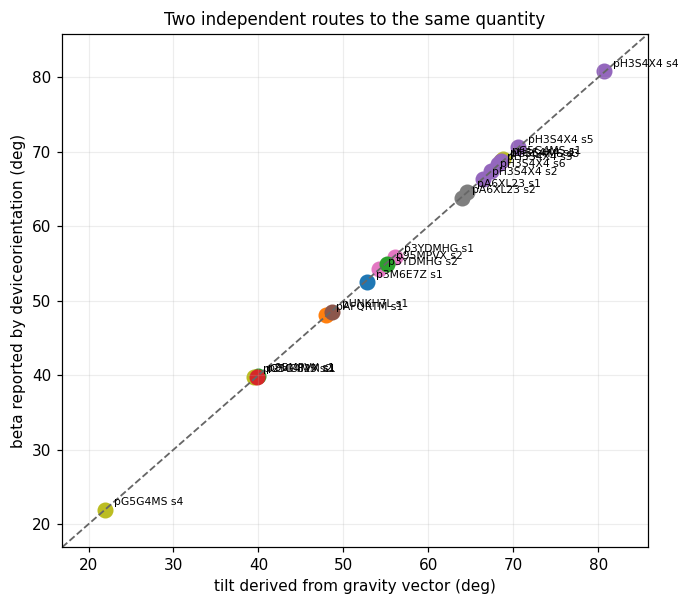

In [20]:
def attitude_check(raw_df):
    rows = []
    for sid in SESSION_ORDER:
        s = raw_df.loc[raw_df['sessionId'] == sid]
        m = s.loc[s['kind'] == MOTION_KIND]
        o = s.loc[s['kind'] == ORIENT_KIND]
        if len(m) < 100 or len(o) < 100:
            continue
        g = {c: pd.to_numeric(m[c], errors='coerce').to_numpy(float) for c in GRAVITY_COLS}
        if any(np.isnan(v).all() for v in g.values()):
            continue
        tilt = np.degrees(np.arctan2(g['payload_agy'],
                                     np.sqrt(g['payload_agx'] ** 2 + g['payload_agz'] ** 2)))
        beta = pd.to_numeric(o['payload_beta'], errors='coerce').to_numpy(float)
        rows.append({'session': SESSION_LABEL.get(sid, sid[:8]),
                     'participantId': s['participantId'].iloc[0],
                     'from_gravity': round(float(abs(np.nanmedian(tilt))), 1),
                     'from_orientation': round(float(np.nanmedian(beta)), 1)})
    return pd.DataFrame(rows)


attitude = attitude_check(raw)


def plot_attitude(att):
    fig, ax = plt.subplots(figsize=(6.4, 5.6))
    for r in att.itertuples():
        ax.scatter(r.from_gravity, r.from_orientation, s=90, color=pcolor(r.participantId))
        ax.annotate(r.session, (r.from_gravity, r.from_orientation), fontsize=7,
                    xytext=(6, 3), textcoords='offset points')
    lims = [min(att[['from_gravity', 'from_orientation']].min()) - 5,
            max(att[['from_gravity', 'from_orientation']].max()) + 5]
    ax.plot(lims, lims, color='0.4', ls='--', lw=1.2)
    ax.set_xlim(*lims); ax.set_ylim(*lims)
    ax.set_xlabel("tilt derived from gravity vector (deg)")
    ax.set_ylabel("beta reported by deviceorientation (deg)")
    ax.set_title("Two independent routes to the same quantity")
    plt.tight_layout(); plt.show(); plt.close(fig)


if len(attitude):
    print(attitude.to_string(index=False))
    r = np.corrcoef(attitude['from_gravity'], attitude['from_orientation'])[0, 1]
    print(f"\nagreement: r = {r:+.4f}")
    print("The two sensors describe the same physical quantity. The gravity channels are")
    print("a redundancy check, not a second source of posture information.")
    plot_attitude(attitude)

## 13. Per-participant summary

Everything above on one page, as descriptive numbers. No scores, no ranking — the point is
to be able to look up what a person's sensors looked like.

Blank cells mean the quantity could not be computed for that person, which is
itself worth noticing.

         sessions  minutes  tilt_deg  tilt_between_session_spread  roll_deg  roll_between_session_spread  idle_epochs  idle_pct  idle_travel_deg_s
p3M6E7Z         1     15.9      52.5                          NaN       0.7                          NaN           32      29.5               7.03
pAFQRTM         1     11.7      48.1                          NaN       1.9                          NaN           13      14.6               4.99
p95MPVX         2     20.3      47.5                         15.1       6.0                          3.1           13      10.4               4.37
pZMC82M         1      7.3      39.8                          NaN       3.8                          NaN            8      25.0              10.27
pH3S4X4         6     44.7      68.5                         14.5      -3.6                         21.8            6       1.0               9.94
pUNKH7L         

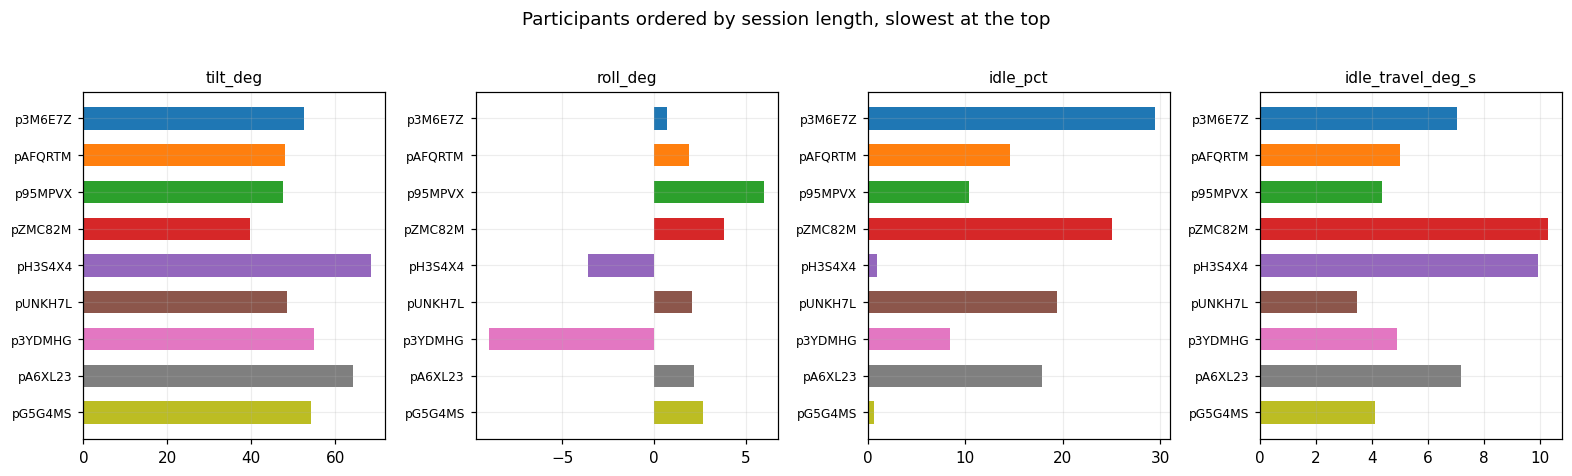

In [21]:
summary = pd.DataFrame(index=PARTICIPANTS)
summary['sessions'] = session_index.groupby('participantId').size().reindex(PARTICIPANTS)
summary['minutes'] = (session_index.groupby('participantId')['duration_s'].sum()
                      .reindex(PARTICIPANTS) / 60).round(1)
for col, short in [('payload_beta', 'tilt'), ('payload_gamma', 'roll')]:
    med, spread = {}, {}
    for p in PARTICIPANTS:
        per_sess = []
        for sid in session_index.loc[session_index['participantId'] == p, 'sessionId']:
            v = pd.to_numeric(raw.loc[(raw['sessionId'] == sid) & (raw['kind'] == ORIENT_KIND), col],
                              errors='coerce').dropna()
            if len(v) >= MIN_ORIENT:
                per_sess.append(float(v.median()))
        med[p] = round(float(np.median(per_sess)), 1) if per_sess else np.nan
        spread[p] = round(float(max(per_sess) - min(per_sess)), 1) if len(per_sess) > 1 else np.nan
    summary[f'{short}_deg'] = pd.Series(med)
    summary[f'{short}_between_session_spread'] = pd.Series(spread)
summary['idle_epochs'] = avail['idle_epochs'].astype(int)
summary['idle_pct'] = avail['idle_pct_of_session']
if len(idle_dyn):
    summary['idle_travel_deg_s'] = (idle_dyn.groupby('participantId')['angular_travel_deg_s']
                                    .median().reindex(PARTICIPANTS).round(2))

print("Blank cells mean the quantity could not be computed for that person, which is")
print("itself worth noticing.\n")
print(summary.to_string())


def plot_summary(sm):
    cols = [c for c in ['tilt_deg', 'roll_deg', 'idle_pct', 'idle_travel_deg_s'] if c in sm]
    fig, axes = plt.subplots(1, len(cols), figsize=(3.6 * len(cols), 4.2))
    for ax, c in zip(np.atleast_1d(axes), cols):
        v = sm[c].dropna()
        ax.barh(range(len(v)), v, color=[pcolor(p) for p in v.index], height=0.6)
        ax.set_yticks(range(len(v))); ax.set_yticklabels(v.index, fontsize=8)
        ax.invert_yaxis(); ax.set_title(c, fontsize=10)
        miss = [p for p in sm.index if p not in v.index]
        if miss:
            ax.text(0.5, 0.02, f"absent: {', '.join(miss)}", transform=ax.transAxes,
                    ha='center', fontsize=7.5, color='#c44e52')
    fig.suptitle("Participants ordered by session length, slowest at the top", y=1.02)
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_summary(summary)

## 14. What the data is like, and what remains open### Things worth carrying forward about these streams**Posture is fixed within a session and can differ between sessions.** Section 2 showsflat traces; Section 4 shows the same person sitting differently on different visits. Sotilt describes the recording at least as much as the person. That is why session-safesplitting matters: an evaluation that mixes windows from one session across training andtesting would be rewarded for recognising the session.**Roll behaves differently from tilt.** One participant holds the phone rolled about 9°one way on both their visits while others sit near zero, and their two sessions agreeclosely. Grip may be more personal than posture, but with two sessions for most peoplethat is an observation rather than a finding.**Nobody put their phone down.** Every idle acceleration distribution sits in the sameplace, well above zero. An earlier guess that one participant's missing tap ring-downmeant a table is not supported by this.**Movement while idle is not just tapping.** Section 9 compares angular travel duringinteraction against during idle, and the idle bars are well above zero — there is genuinehand movement underneath the interaction.**The fastest participant cannot be described by any idle measure.** Not a data fault. Itis what "never stops interacting" looks like in a table.**Absolute posture is context, not identity.** One participant confirmed they varied
body position deliberately between sessions, which accounts for the between-session splits
in Section 4. Absolute tilt therefore belongs on the context side of the design — useful
for deciding how much to trust a window — rather than as an identity input.

**Centring has to look backwards.** Section 5 works through the options. The session median
is the right choice for describing data and unavailable as a feature, because it needs the
whole session. A rolling median over the last 30 seconds is causal, is far steadier than
anchoring on a single reading at t=0, and follows the person when they reposition.

**Most of the visible separation does not survive centring.** Absolute tilt spreads
sessions over roughly 59°; the centred residual mostly sits between 2.5° and 3.9°, with
three sessions elevated for identifiable reasons (two genuine repositions, one genuine
wild excursion in pAFQRTM s1). That is the correct result rather than a disappointing
one — it means the striking separations earlier in this notebook were largely body
position.

**The questionnaire cannot record posture.** Every session in the cohort self-reports
'Sitting' while the sensor spans 22–69°, because the available options are Sitting /
Standing / Walking and there is no option for lying down. `ctxPosture` has zero variance
for reasons that are about the instrument, not the participants.

### Data-quality notes- **`alpha` wraps constantly** and averaging it naively is wrong by up to 176°. Anything circular needs sin/cos treatment. **`beta` wraps too, in one session** (pAFQRTM s1) — the same sin/cos-style unwrap now applies to beta wherever it feeds a statistic or plot.- **Gravity channels duplicate `deviceorientation`** at r ≈ 1.0. Useful as a cross-check,  not as extra information.- **The sampling rate puts hand tremor at or past the Nyquist limit**, so high-frequency  energy is partly aliased. Raising the motion rate would be the single change that most  improves what this notebook can see.### Open questions the data cannot currently answer- Is roll stable over more than two sessions, or does it drift like tilt does?
- Does anything survive centring in a way that is stable across sessions? The residual
  distributions here overlap heavily, but overlap pooled across people is not the same
  question as whether one person's residual looks like their own on another day.
- Is the shape of the baseline path — settles quickly, drifts continuously, steps once —
  a trait? It is visibly different between sessions here, but nobody has enough sessions
  to say whether it is stable within a person.
- How long a baseline memory is right? 30 seconds is a starting choice, not a tuned one,
  and the answer probably depends on whether a posture change should count as a signal or
  as something to be tracked out.- Does idle restlessness mean anything about a person, or does it mostly track how  comfortable they were that day? Repeat sessions under different conditions would  separate those.- Would a higher motion sample rate reveal structure in the fast band that is currently  folded down and unreadable?- Everyone here is on their own handset, so any sensor difference between people is also  a difference between devices. Shared-device data is what separates those.

In [22]:
OUT_DIR = Path("../../data/interim")
OUT_DIR.mkdir(parents=True, exist_ok=True)

_exports = {
    'posture_session_angles.csv': angle_summary,
    'posture_windows.csv': windows,
    'posture_idle_runs.csv': runs,
    'posture_idle_dynamics.csv': idle_dyn,
    'posture_alpha_wraps.csv': wraps,
    'posture_attitude_crosscheck.csv': attitude,
    'posture_participant_summary.csv': summary.reset_index().rename(columns={'index': 'participantId'}),
    'posture_reported_vs_measured.csv': posture_check,
    'posture_anchor_error.csv': anchor_err,
    'posture_residual_summary.csv': _rs,
    'posture_relative_windows.csv': rel_windows,
    'posture_baseline_drift.csv': baseline_drift,
}
for name, frame in _exports.items():
    frame.to_csv(OUT_DIR / name, index=False)
    print(f"wrote {OUT_DIR / name}  ({len(frame):,} rows)")

wrote ../../data/interim/posture_session_angles.csv  (20 rows)
wrote ../../data/interim/posture_windows.csv  (3,119 rows)
wrote ../../data/interim/posture_idle_runs.csv  (115 rows)
wrote ../../data/interim/posture_idle_dynamics.csv  (115 rows)
wrote ../../data/interim/posture_alpha_wraps.csv  (20 rows)
wrote ../../data/interim/posture_attitude_crosscheck.csv  (20 rows)
wrote ../../data/interim/posture_participant_summary.csv  (9 rows)
wrote ../../data/interim/posture_reported_vs_measured.csv  (20 rows)
wrote ../../data/interim/posture_anchor_error.csv  (20 rows)
wrote ../../data/interim/posture_residual_summary.csv  (20 rows)
wrote ../../data/interim/posture_relative_windows.csv  (3,096 rows)
wrote ../../data/interim/posture_baseline_drift.csv  (20 rows)
